# Mission 17. 서울 안심택배함 공급·수요 불균형 및 추가 설치 우선지역 분석

> **GCS → BigQuery → Python → Looker Studio**

서울시 안심택배함의 현재 공급, 실제 이용, 자치구별 1인가구 수요를 함께 비교해 단순 설치 개수만으로는 보이지 않는 공급·수요 불균형을 진단했다. 현재 단면뿐 아니라 2021~2025년 동일 시설의 이용 추세와 시설별 편차까지 확인하여, 자치구별 추가 설치 여부를 더 신중하게 판단하는 것을 목표로 한다.


## 분석 질문

1. 1인가구 수요에 비해 안심택배함 공급이 부족한 자치구는 어디인가?
2. 공급 압력이 높으면서 실제 이용도 높은 지역은 어디인가?
3. 현재 이용 수준과 2021~2025년 장기 이용 추세는 같은 방향을 보이는가?
4. 자치구 평균 안에서 시설별 이용 효율 차이는 얼마나 큰가?
5. 위 결과를 종합했을 때 증설·유지·운영 점검·구조 재검토 중 어떤 대응이 필요한가?

## 활용 데이터

| 데이터 | 기준 | 활용 목적 |
|---|---|---|
| 서울 열린데이터광장 `safeOpenBox` | 수집일 기준 현재 시설 | 안심택배함 위치·자치구·좌표 |
| 서울시 안심택배함 점유율/이용건수 | 2021~2026년 상반기 | 시설별 이용 실적과 장기 추세 |
| KOSIS 성·연령별 1인가구 | 2025년 | 자치구별 잠재 수요 |
| 시군구 경계 SHP | 2025 기준 | Looker Studio 지도 시각화 |

## 파이프라인

`공공데이터 수집 → 로컬 정제/품질검사 → GCS 적재 → BigQuery SQL·dbt 모델링 → Python 추가 분석 → BigQuery 재적재 → Looker Studio`

(BigQuery SQL과 dbt 모델/YAML은 GitHub 저장소에서 별도로 관리하였습니다. 이 노트북은 수집, 정제, 품질검사, BigQuery 연동, Python 심화 분석, 재적재 과정이 중심입니다.)

# 1. 라이브러리 호출 및 서울시 안심택배함 위치 데이터 수집

In [ ]:
import hashlib
import os
import time
from datetime import datetime
from hashlib import sha256
from pathlib import Path
import geopandas as gpd
import google.auth
import koreanize_matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import load_dotenv
from google.cloud import bigquery
from scipy.stats import spearmanr


In [2]:
load_dotenv()
api_key = os.getenv("SEOUL_API_KEY")

if not api_key:
    raise ValueError(".env에서 SEOUL_API_KEY를 찾을 수 없습니다.")

service_name = "safeOpenBox"
url = (
    f"http://openapi.seoul.go.kr:8088/"
    f"{api_key}/json/{service_name}/1/5/"
)

response = requests.get(url, timeout=30)
payload = response.json()

if service_name not in payload:
    raise ValueError(f"API 오류: {payload}")

result = payload[service_name]
df_sample = pd.DataFrame(result["row"])

print("응답 메시지:", result["RESULT"]["MESSAGE"])
print("전체 데이터 수:", result["list_total_count"])
display(df_sample)


응답 메시지: 정상 처리되었습니다
전체 데이터 수: 232


,ADDRDETAIL,ANSIMINM,ANSIMIADDR,WGSXPT,WGSYPT
0,,국사봉체육관,,37.4915565,126.9417864
1,,충무창업큐브,광희동 퇴계로 265,37.562970,127.001200
2,,강동구 평생학습관,구천면로 395,37.550990,127.142690
3,,미성체육관,난우16길 37,37.477810,126.919120
4,,응봉동공영주차장,독서당로63길 40,37.5533232,127.0307171


📍 현재 안심택배함 위치는 232개 시설로 확인되었다. 샘플 단계에서 일부 시설의 자치구와 주소가 빈 문자열로 들어온 것도 함께 확인되어 이후 품질검사 대상으로 넘겼다.


In [3]:
def fetch_all_seoul_data(service_name, page_size=100):
    """서울시 Open API 데이터를 페이지 단위로 전체 수집합니다."""

    all_rows = []
    start_index = 1

    while True:
        end_index = start_index + page_size - 1

        page_url = (
            f"http://openapi.seoul.go.kr:8088/"
            f"{api_key}/json/{service_name}/{start_index}/{end_index}/"
        )

        response = requests.get(page_url, timeout=30)

        if response.status_code != 200:
            raise RuntimeError(f"HTTP 오류: {response.status_code}")

        payload = response.json()

        if service_name not in payload:
            raise ValueError(f"API 오류: {payload}")

        result = payload[service_name]
        total_count = int(result["list_total_count"])
        page_rows = result.get("row", [])

        all_rows.extend(page_rows)

        print(
            f"{start_index:,}~{min(end_index, total_count):,}행 수집 "
            f"(누적 {len(all_rows):,}/{total_count:,})"
        )

        if end_index >= total_count:
            break

        start_index = end_index + 1
        time.sleep(0.2)

    return pd.DataFrame(all_rows)

df_lockers_raw = fetch_all_seoul_data(
    service_name="safeOpenBox",
    page_size=100
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

collection_date = datetime.now().strftime("%Y%m%d")
locker_file = raw_dir / f"safe_locker_locations_{collection_date}.csv"

df_lockers_raw.to_csv(
    locker_file,
    index=False,
    encoding="utf-8-sig"
)

print("\n수집 완료:", len(df_lockers_raw), "행")
print("저장 위치:", locker_file)
display(df_lockers_raw.head())


1~100행 수집 (누적 100/232)
101~200행 수집 (누적 200/232)
201~232행 수집 (누적 232/232)

수집 완료: 232 행
저장 위치: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\raw\safe_locker_locations_20260826.csv


,ADDRDETAIL,ANSIMINM,ANSIMIADDR,WGSXPT,WGSYPT
0,,국사봉체육관,,37.4915565,126.9417864
1,,충무창업큐브,광희동 퇴계로 265,37.562970,127.001200
2,,강동구 평생학습관,구천면로 395,37.550990,127.142690
3,,미성체육관,난우16길 37,37.477810,126.919120
4,,응봉동공영주차장,독서당로63길 40,37.5533232,127.0307171


📍 100건 단위로 100 → 200 → 232까지 페이지네이션이 완료되었고, 총 232행을 원본 CSV로 보존했다.


# 2. 위치 데이터 품질 확인

In [4]:
quality_report = pd.DataFrame({
    "데이터타입": df_lockers_raw.dtypes.astype(str),
    "결측치수": df_lockers_raw.isna().sum(),
    "빈문자열수": (
        df_lockers_raw
        .fillna("")
        .astype(str)
        .apply(lambda col: col.str.strip().eq("").sum())
    ),
    "고유값수": df_lockers_raw.nunique(dropna=True)
})

print("전체 행 수:", len(df_lockers_raw))
print("완전 중복 행 수:", df_lockers_raw.duplicated().sum())

display(quality_report)

display(
    df_lockers_raw[["WGSXPT", "WGSYPT"]]
    .apply(pd.to_numeric, errors="coerce")
    .describe()
)


전체 행 수: 232
완전 중복 행 수: 0


,데이터타입,결측치수,빈문자열수,고유값수
ADDRDETAIL,str,0,8,26
ANSIMINM,str,0,0,232
ANSIMIADDR,str,0,1,232
WGSXPT,str,0,0,232
WGSYPT,str,0,0,232


,WGSXPT,WGSYPT
count,232.000000,232.000000
mean,37.546546,126.982128
std,0.051343,0.085790
min,37.440259,126.810074
25%,37.502652,126.914541
50%,37.545753,126.976350
75%,37.578281,127.046723
max,37.678691,127.148534


📍 완전 중복은 0건이었다. 다만 ADDRDETAIL은 8건, ANSIMIADDR은 1건이 빈 문자열이었으며 좌표 범위는 모두 서울권의 위/경도 범위 안에 들어왔다.


In [5]:
blank_district = (
    df_lockers_raw["ADDRDETAIL"]
    .astype(str)
    .str.strip()
    .eq("")
)

blank_address = (
    df_lockers_raw["ANSIMIADDR"]
    .astype(str)
    .str.strip()
    .eq("")
)

problem_rows = df_lockers_raw[
    blank_district | blank_address
].copy()

display(problem_rows)


,ADDRDETAIL,ANSIMINM,ANSIMIADDR,WGSXPT,WGSYPT
0,,국사봉체육관,,37.4915565,126.9417864
1,,충무창업큐브,광희동 퇴계로 265,37.562970,127.001200
2,,강동구 평생학습관,구천면로 395,37.550990,127.142690
3,,미성체육관,난우16길 37,37.477810,126.919120
4,,응봉동공영주차장,독서당로63길 40,37.5533232,127.0307171
5,,양재1동 반딧불센터,양재천로 125-10,37.4785771,127.0413752
6,,천호청소년문화의집,천중로 61,37.545150,127.128790
7,,구립안말경로당,풍성로45길 11,37.531220,127.129853


📍 자치구가 비어 있는 시설 8곳이 확인됐고, 이 중 국사봉체육관은 주소도 비어 있었다. 해당 값은 공식 시설정보를 근거로 별도 보정한다.


In [6]:
df_lockers_clean = df_lockers_raw.rename(
    columns={
        "ADDRDETAIL": "district",
        "ANSIMINM": "locker_name",
        "ANSIMIADDR": "address",
        "WGSXPT": "latitude",
        "WGSYPT": "longitude",
    }
).copy()

for column in ["district", "locker_name", "address"]:
    df_lockers_clean[column] = (
        df_lockers_clean[column]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace("", pd.NA)
    )

df_lockers_clean["latitude"] = pd.to_numeric(
    df_lockers_clean["latitude"],
    errors="coerce"
)

df_lockers_clean["longitude"] = pd.to_numeric(
    df_lockers_clean["longitude"],
    errors="coerce"
)

district_corrections = {
    "국사봉체육관": "관악구",
    "충무창업큐브": "중구",
    "강동구 평생학습관": "강동구",
    "미성체육관": "관악구",
    "응봉동공영주차장": "성동구",
    "양재1동 반딧불센터": "서초구",
    "천호청소년문화의집": "강동구",
    "구립안말경로당": "강동구",
}

missing_district = df_lockers_clean["district"].isna()

df_lockers_clean.loc[missing_district, "district"] = (
    df_lockers_clean.loc[missing_district, "locker_name"]
    .map(district_corrections)
)

df_lockers_clean["district_source"] = "seoul_open_api"
df_lockers_clean.loc[
    missing_district, "district_source"
] = "official_reference"

missing_address = df_lockers_clean["address"].isna()

df_lockers_clean.loc[
    df_lockers_clean["locker_name"].eq("국사봉체육관"),
    "address"
] = "국회단지길 144"

df_lockers_clean["address_source"] = "seoul_open_api"
df_lockers_clean.loc[
    missing_address, "address_source"
] = "official_reference"

def make_full_address(row):
    address = row["address"]
    district = row["district"]

    if address.startswith("서울"):
        return address

    if address.startswith(district):
        return f"서울특별시 {address}"

    return f"서울특별시 {district} {address}"

df_lockers_clean["full_address"] = df_lockers_clean.apply(
    make_full_address,
    axis=1
)

def create_locker_id(row):
    key = (
        f"{row['locker_name']}|"
        f"{row['latitude']:.7f}|"
        f"{row['longitude']:.7f}"
    )
    return "LKR_" + hashlib.sha256(
        key.encode("utf-8")
    ).hexdigest()[:12]

df_lockers_clean["locker_id"] = df_lockers_clean.apply(
    create_locker_id,
    axis=1
)

df_lockers_clean["collection_date"] = pd.Timestamp.now(
    tz="Asia/Seoul"
).date()

df_lockers_clean["quality_status"] = "original"
df_lockers_clean.loc[
    missing_district | missing_address,
    "quality_status"
] = "corrected"

df_lockers_clean = df_lockers_clean[
    [
        "locker_id",
        "district",
        "locker_name",
        "address",
        "full_address",
        "latitude",
        "longitude",
        "collection_date",
        "district_source",
        "address_source",
        "quality_status",
    ]
]

assert len(df_lockers_clean) == 232
assert df_lockers_clean["locker_id"].is_unique
assert df_lockers_clean["district"].notna().all()
assert df_lockers_clean["address"].notna().all()
assert df_lockers_clean["latitude"].between(37, 38).all()
assert df_lockers_clean["longitude"].between(126, 128).all()

processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

clean_file = (
    processed_dir
    / f"safe_locker_locations_clean_{collection_date}.csv"
)

df_lockers_clean.to_csv(
    clean_file,
    index=False,
    encoding="utf-8-sig"
)

print("정제 완료:", len(df_lockers_clean), "행")
print("자치구 수:", df_lockers_clean["district"].nunique())
print("고유 ID 중복:", df_lockers_clean["locker_id"].duplicated().sum())
print("저장 위치:", clean_file)

display(
    df_lockers_clean[
        df_lockers_clean["quality_status"].eq("corrected")
    ]
)


정제 완료: 232 행
자치구 수: 25
고유 ID 중복: 0
저장 위치: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\safe_locker_locations_clean_20260826.csv


,locker_id,district,locker_name,address,full_address,latitude,longitude,collection_date,district_source,address_source,quality_status
0,LKR_a2147b8d6417,관악구,국사봉체육관,국회단지길 144,서울특별시 관악구 국회단지길 144,37.491557,126.941786,2026-08-26,official_reference,official_reference,corrected
1,LKR_395f4baffd7b,중구,충무창업큐브,광희동 퇴계로 265,서울특별시 중구 광희동 퇴계로 265,37.562970,127.001200,2026-08-26,official_reference,seoul_open_api,corrected
2,LKR_eae21d5abe1a,강동구,강동구 평생학습관,구천면로 395,서울특별시 강동구 구천면로 395,37.550990,127.142690,2026-08-26,official_reference,seoul_open_api,corrected
3,LKR_f090964198dc,관악구,미성체육관,난우16길 37,서울특별시 관악구 난우16길 37,37.477810,126.919120,2026-08-26,official_reference,seoul_open_api,corrected
4,LKR_c0d5c759d29c,성동구,응봉동공영주차장,독서당로63길 40,서울특별시 성동구 독서당로63길 40,37.553323,127.030717,2026-08-26,official_reference,seoul_open_api,corrected
5,LKR_1f59fee2a818,서초구,양재1동 반딧불센터,양재천로 125-10,서울특별시 서초구 양재천로 125-10,37.478577,127.041375,2026-08-26,official_reference,seoul_open_api,corrected
6,LKR_8482980bbedc,강동구,천호청소년문화의집,천중로 61,서울특별시 강동구 천중로 61,37.545150,127.128790,2026-08-26,official_reference,seoul_open_api,corrected
7,LKR_887abf8acf07,강동구,구립안말경로당,풍성로45길 11,서울특별시 강동구 풍성로45길 11,37.531220,127.129853,2026-08-26,official_reference,seoul_open_api,corrected


📍 232개 시설이 모두 25개 자치구에 매핑되었고, 생성한 locker_id 중복은 0건이다. 보정한 값은 quality_status = corrected와 출처 컬럼으로 구분해 원본값과 섞이지 않도록 했다.


# 3. 안심택배함 점유율·이용건수 정제

In [7]:
usage_file = (
    raw_dir
    / "safe_locker_annual_occupancy_202606.xlsx"
)

excel_file = pd.ExcelFile(usage_file)

print("Excel 시트 목록:", excel_file.sheet_names)

for sheet_name in excel_file.sheet_names:
    preview = pd.read_excel(
        usage_file,
        sheet_name=sheet_name,
        header=None
    )

    print(
        f"\n시트명: {sheet_name} / "
        f"크기: {preview.shape[0]}행 × {preview.shape[1]}열"
    )

    display(preview.head(12))


Excel 시트 목록: ['구별 연간 점유율', '개소별 이용건수']

시트명: 구별 연간 점유율 / 크기: 277행 × 13열


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,자치구,시설물명,주소,운영여부,설치연도,철거연도,칸수,2021년,2022년,2023년,2024년,2025년,2026년 6월
1,종로구,청운효자동 자치회관,자하문로19길 36,운영,2017,NaN,19,0.35,0.27,0.24,0.280108,0.265448,0.266627
2,NaN,종로육아종합지원센터,성균관로1길 6-3,운영,2015,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,숭인1동 주민센터,지봉로 86,운영,2014,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,숭인제2동주민센터,종로65길 10,운영,2020,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,종로구민회관,지봉로5길 7-5,운영,2019,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN
6,중구,약수동공영주차장,동호로8다길 22,철거,2017,2025,12,0.21,0.19,0.19,0.176101,0.192303,0.185295
7,NaN,버티 공영주차장,동호로17길 270,운영,2017,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,장충체육관 후문,동호로 241,운영,2016,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,약수교회 식당입구,다산로8길 32,철거,2014,2025,19,NaN,NaN,NaN,NaN,NaN,NaN



시트명: 개소별 이용건수 / 크기: 277행 × 13열


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,자치구,시설물명,주소,운영여부,설치연도,철거연도,칸수,2021년,2022년,2023년,2024년,2025년,2026년 6월
1,종로구,청운효자동 자치회관,자하문로19길 36,운영,2017,NaN,19,2425,2219,2036,1969,2045,803
2,NaN,종로육아종합지원센터,성균관로1길 6-3,운영,2015,NaN,19,3014,2637,2143,3157,2733,1614
3,NaN,숭인1동 주민센터,지봉로 86,운영,2014,NaN,19,3252,2438,1858,2110,2230,819
4,NaN,숭인제2동주민센터,종로65길 10,운영,2020,NaN,12,176,406,505,628,529,307
5,NaN,종로구민회관,지봉로5길 7-5,운영,2019,NaN,12,960,777,806,959,856,552
6,중구,약수동공영주차장,동호로8다길 22,철거,2017,2025,12,1226,1203,1118,1248,-,-
7,NaN,버티 공영주차장,동호로17길 270,운영,2017,NaN,19,2442,2291,2217,1892,1647,928
8,NaN,장충체육관 후문,동호로 241,운영,2016,NaN,19,1455,1552,1167,1530,2076,978
9,NaN,약수교회 식당입구,다산로8길 32,철거,2014,2025,19,1565,1270,1264,1416,-,-


In [8]:
project_dir = Path.cwd()

if project_dir.name == "notebooks":
    project_dir = project_dir.parent

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

usage_file = (
    raw_dir
    / "safe_locker_annual_occupancy_202606.xlsx"
)

if not usage_file.exists():
    raise FileNotFoundError(
        f"Excel 파일을 찾을 수 없습니다: {usage_file}"
    )

print("Excel 파일 확인:", usage_file)

sheet_files = {
    "구별 연간 점유율":
        "safe_locker_occupancy_raw_202606.csv",

    "개소별 이용건수":
        "safe_locker_usage_raw_202606.csv",
}

raw_sheets = {}

for sheet_name, csv_name in sheet_files.items():

    raw_df = pd.read_excel(
        usage_file,
        sheet_name=sheet_name,
        header=0
    )

    raw_df = raw_df.iloc[:, :13].copy()

    raw_sheets[sheet_name] = raw_df

    raw_csv_path = raw_dir / csv_name

    raw_df.to_csv(
        raw_csv_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"원본 CSV 저장: {raw_csv_path} "
        f"({len(raw_df):,}행)"
    )

column_names = [
    "district",
    "facility_name",
    "address",
    "operation_status",
    "installed_year",
    "removed_year",
    "locker_count",
    "2021",
    "2022",
    "2023",
    "2024",
    "2025",
    "2026_h1",
]

period_columns = [
    "2021",
    "2022",
    "2023",
    "2024",
    "2025",
    "2026_h1",
]

def clean_locker_sheet(raw_df, sheet_name):

    df = raw_df.copy()

    if df.shape[1] < 13:
        raise ValueError(
            f"{sheet_name} 시트의 컬럼 수가 "
            f"13개보다 적습니다: {df.shape[1]}개"
        )

    df = df.iloc[:, :13].copy()
    df.columns = column_names

    text_columns = [
        "district",
        "facility_name",
        "address",
        "operation_status",
    ]

    for col in text_columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .replace(r"^\s*$", pd.NA, regex=True)
            .replace(
                to_replace=r"^\s*[-–—]\s*$",
                value=pd.NA,
                regex=True
            )
        )

    # Excel 병합 셀로 비어 있는 자치구를 아래 행까지 채움
    df["district"] = df["district"].ffill()

    df = df[
        df["facility_name"].notna()
    ].copy()

    for col in period_columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        ).astype("Float64")

    for col in [
        "installed_year",
        "removed_year",
    ]:
        year_text = (
            df[col]
            .astype("string")
            .str.extract(
                r"((?:19|20)\d{2})",
                expand=False
            )
        )

        df[col] = pd.to_numeric(
            year_text,
            errors="coerce"
        ).astype("Int64")

    locker_count_numeric = pd.to_numeric(
        df["locker_count"],
        errors="coerce"
    ).astype("Float64")

    non_integer_count = locker_count_numeric[
        locker_count_numeric.notna()
        & (locker_count_numeric % 1 != 0)
    ]

    if not non_integer_count.empty:
        print(
            f"{sheet_name} - 정수가 아닌 칸 수:",
            non_integer_count.unique().tolist()
        )

    df["locker_count"] = (
        locker_count_numeric
        .round()
        .astype("Int64")
    )

    def make_stat_id(row):

        values = [
            row["district"],
            row["facility_name"],
            row["address"],
            row["installed_year"],
        ]

        key = "|".join(
            ""
            if pd.isna(value)
            else str(value)
            for value in values
        )

        hash_value = sha256(
            key.encode("utf-8")
        ).hexdigest()[:12]

        return f"STAT_{hash_value}"

    df.insert(
        0,
        "locker_stat_id",
        df.apply(
            make_stat_id,
            axis=1
        )
    )

    df["snapshot_date"] = pd.Timestamp(
        "2026-06-30"
    )

    df["source_sheet"] = sheet_name

    return df.reset_index(drop=True)

occupancy_wide = clean_locker_sheet(
    raw_sheets["구별 연간 점유율"],
    "구별 연간 점유율"
)

usage_wide = clean_locker_sheet(
    raw_sheets["개소별 이용건수"],
    "개소별 이용건수"
)

occupancy_ids = set(
    occupancy_wide["locker_stat_id"]
)

usage_ids = set(
    usage_wide["locker_stat_id"]
)

id_difference = (
    occupancy_ids.symmetric_difference(
        usage_ids
    )
)

print("\n========== 정제 결과 ==========")

print(
    "점유율 데이터:",
    f"{len(occupancy_wide):,}행"
)

print(
    "이용건수 데이터:",
    f"{len(usage_wide):,}행"
)

print(
    "점유율 ID 중복:",
    occupancy_wide[
        "locker_stat_id"
    ].duplicated().sum()
)

print(
    "이용건수 ID 중복:",
    usage_wide[
        "locker_stat_id"
    ].duplicated().sum()
)

print(
    "두 시트 ID 불일치:",
    len(id_difference)
)

print(
    "자치구 수:",
    occupancy_wide[
        "district"
    ].nunique()
)

print("\n========== 운영 상태 ==========")

operation_summary = (
    occupancy_wide[
        "operation_status"
    ]
    .value_counts(dropna=False)
    .rename_axis("operation_status")
    .reset_index(name="facility_count")
)

display(operation_summary)

id_columns = [
    "locker_stat_id",
    "district",
    "facility_name",
    "address",
    "operation_status",
    "installed_year",
    "removed_year",
    "locker_count",
    "snapshot_date",
]

occupancy_long = occupancy_wide.melt(
    id_vars=id_columns,
    value_vars=period_columns,
    var_name="period",
    value_name="occupancy_rate"
)

usage_long = usage_wide[
    [
        "locker_stat_id",
        *period_columns,
    ]
].melt(
    id_vars=["locker_stat_id"],
    value_vars=period_columns,
    var_name="period",
    value_name="usage_count"
)

locker_metrics_long = occupancy_long.merge(
    usage_long,
    on=[
        "locker_stat_id",
        "period",
    ],
    how="left",
    validate="one_to_one"
)

period_info = pd.DataFrame({
    "period": [
        "2021",
        "2022",
        "2023",
        "2024",
        "2025",
        "2026_h1",
    ],

    "year": [
        2021,
        2022,
        2023,
        2024,
        2025,
        2026,
    ],

    "period_end": pd.to_datetime([
        "2021-12-31",
        "2022-12-31",
        "2023-12-31",
        "2024-12-31",
        "2025-12-31",
        "2026-06-30",
    ]),

    "months_observed": [
        12,
        12,
        12,
        12,
        12,
        6,
    ],

    "is_partial_year": [
        False,
        False,
        False,
        False,
        False,
        True,
    ],
})

locker_metrics_long = (
    locker_metrics_long.merge(
        period_info,
        on="period",
        how="left",
        validate="many_to_one"
    )
)

locker_metrics_long[
    "occupancy_rate_pct"
] = (
    locker_metrics_long[
        "occupancy_rate"
    ] * 100
)

# 연간/반기 자료를 비교할 수 있도록 월평균으로 표준화
locker_metrics_long[
    "monthly_avg_usage"
] = (
    locker_metrics_long[
        "usage_count"
    ]
    / locker_metrics_long[
        "months_observed"
    ]
)

occupancy_path = (
    processed_dir
    / "safe_locker_occupancy_clean_202606.csv"
)

usage_path = (
    processed_dir
    / "safe_locker_usage_clean_202606.csv"
)

metrics_path = (
    processed_dir
    / "safe_locker_metrics_long_202606.csv"
)

occupancy_wide.to_csv(
    occupancy_path,
    index=False,
    encoding="utf-8-sig"
)

usage_wide.to_csv(
    usage_path,
    index=False,
    encoding="utf-8-sig"
)

locker_metrics_long.to_csv(
    metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n========== 저장 완료 ==========")

print("점유율:", occupancy_path)
print("이용건수:", usage_path)
print("통합 분석용:", metrics_path)

print(
    "\n통합 데이터 크기:",
    locker_metrics_long.shape
)

print(
    "통합 데이터 완전 중복:",
    locker_metrics_long.duplicated().sum()
)

display(
    locker_metrics_long.head(10)
)


Excel 파일 확인: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\raw\safe_locker_annual_occupancy_202606.xlsx
원본 CSV 저장: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\raw\safe_locker_occupancy_raw_202606.csv (276행)
원본 CSV 저장: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\raw\safe_locker_usage_raw_202606.csv (276행)

========== 정제 결과 ==========
점유율 데이터: 276행
이용건수 데이터: 276행
점유율 ID 중복: 0
이용건수 ID 중복: 0
두 시트 ID 불일치: 10
자치구 수: 25

========== 운영 상태 ==========


,operation_status,facility_count
0,운영,222
1,철거,54



========== 저장 완료 ==========
점유율: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\safe_locker_occupancy_clean_202606.csv
이용건수: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\safe_locker_usage_clean_202606.csv
통합 분석용: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\safe_locker_metrics_long_202606.csv

통합 데이터 크기: (1656, 18)
통합 데이터 완전 중복: 0


,locker_stat_id,district,facility_name,address,operation_status,installed_year,removed_year,locker_count,snapshot_date,period,occupancy_rate,usage_count,year,period_end,months_observed,is_partial_year,occupancy_rate_pct,monthly_avg_usage
0,STAT_1deb19b87d6c,종로구,청운효자동 자치회관,자하문로19길 36,운영,2017,<NA>,19,2026-06-30,2021,0.35,2425.0,2021,2021-12-31,12,False,35.0,202.083333
1,STAT_96982af9e8d2,종로구,종로육아종합지원센터,성균관로1길 6-3,운영,2015,<NA>,19,2026-06-30,2021,<NA>,3014.0,2021,2021-12-31,12,False,<NA>,251.166667
2,STAT_eb22f2a36133,종로구,숭인1동 주민센터,지봉로 86,운영,2014,<NA>,19,2026-06-30,2021,<NA>,3252.0,2021,2021-12-31,12,False,<NA>,271.0
3,STAT_ab55a49f8df8,종로구,숭인제2동주민센터,종로65길 10,운영,2020,<NA>,12,2026-06-30,2021,<NA>,176.0,2021,2021-12-31,12,False,<NA>,14.666667
4,STAT_4507e8e15712,종로구,종로구민회관,지봉로5길 7-5,운영,2019,<NA>,12,2026-06-30,2021,<NA>,960.0,2021,2021-12-31,12,False,<NA>,80.0
5,STAT_5d2596e487d0,중구,약수동공영주차장,동호로8다길 22,철거,2017,2025,12,2026-06-30,2021,0.21,1226.0,2021,2021-12-31,12,False,21.0,102.166667
6,STAT_69f668df68d1,중구,버티 공영주차장,동호로17길 270,운영,2017,<NA>,19,2026-06-30,2021,<NA>,2442.0,2021,2021-12-31,12,False,<NA>,203.5
7,STAT_e3145d04f78b,중구,장충체육관 후문,동호로 241,운영,2016,<NA>,19,2026-06-30,2021,<NA>,1455.0,2021,2021-12-31,12,False,<NA>,121.25
8,STAT_dc34337e60ee,중구,약수교회 식당입구,다산로8길 32,철거,2014,2025,19,2026-06-30,2021,<NA>,1565.0,2021,2021-12-31,12,False,<NA>,130.416667
9,STAT_be885827267e,중구,장충공영주차장,장충동2가 192-129,철거,2018,2024,12,2026-06-30,2021,<NA>,545.0,2021,2021-12-31,12,False,<NA>,45.416667


📍 시설 기준 276행을 확보했으며 운영 222개, 철거 54개로 구분됐다. 6개 기간을 long 형태로 변환해 1,656행의 통합 시계열 테이블을 만들었다. 초기 ID 기준으로 두 시트 간 불일치가 발견되어 다음 단계에서 원본 메타데이터 차이를 점검했다.


In [9]:
compare_columns = [
    "district",
    "facility_name",
    "address",
    "operation_status",
    "installed_year",
    "removed_year",
    "locker_count",
]

occupancy_compare = (
    occupancy_wide[compare_columns]
    .reset_index(drop=True)
)

usage_compare = (
    usage_wide[compare_columns]
    .reset_index(drop=True)
)

same_values = (
    occupancy_compare.eq(usage_compare)
    | (
        occupancy_compare.isna()
        & usage_compare.isna()
    )
)

different_rows = ~same_values.all(axis=1)

print("정보가 다른 시설 행 수:", different_rows.sum())

difference_by_column = pd.DataFrame({
    "column": compare_columns,
    "different_count": [
        (~same_values[col]).sum()
        for col in compare_columns
    ],
})

display(difference_by_column)

comparison_result = pd.DataFrame({
    "excel_row": occupancy_compare.index + 2
})

for col in compare_columns:
    comparison_result[f"{col}_점유율"] = (
        occupancy_compare[col]
    )

    comparison_result[f"{col}_이용건수"] = (
        usage_compare[col]
    )

display(
    comparison_result.loc[different_rows]
)


정보가 다른 시설 행 수: 1


,column,different_count
0,district,0
1,facility_name,0
2,address,0
3,operation_status,0
4,installed_year,1
5,removed_year,0
6,locker_count,0


,excel_row,district_점유율,district_이용건수,facility_name_점유율,facility_name_이용건수,address_점유율,address_이용건수,operation_status_점유율,operation_status_이용건수,installed_year_점유율,installed_year_이용건수,removed_year_점유율,removed_year_이용건수,locker_count_점유율,locker_count_이용건수
119,121,서대문구,서대문구,신한은행_남가좌동점,신한은행_남가좌동점,서대문구 수색로2길 36(남가좌동),서대문구 수색로2길 36(남가좌동),운영,운영,2020,2022,<NA>,<NA>,12,12


📍 두 시트의 시설정보 차이는 1개 시설의 설치연도에서만 확인됐다. 신한은행_남가좌동점이 점유율 시트에서는 2020년, 이용건수 시트에서는 2022년으로 기록되어 있었다.


In [10]:
def rebuild_stat_id(df):

    key_series = (
        df["district"]
        .fillna("")
        .astype(str)
        .str.strip()

        + "|"

        + df["facility_name"]
        .fillna("")
        .astype(str)
        .str.strip()

        + "|"

        + df["address"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    return key_series.map(
        lambda value:
        "STAT_"
        + sha256(
            value.encode("utf-8")
        ).hexdigest()[:12]
    )

occupancy_wide["locker_stat_id"] = (
    rebuild_stat_id(occupancy_wide)
)

usage_wide["locker_stat_id"] = (
    rebuild_stat_id(usage_wide)
)

occupancy_ids = set(
    occupancy_wide["locker_stat_id"]
)

usage_ids = set(
    usage_wide["locker_stat_id"]
)

print(
    "점유율 ID 중복:",
    occupancy_wide[
        "locker_stat_id"
    ].duplicated().sum()
)

print(
    "이용건수 ID 중복:",
    usage_wide[
        "locker_stat_id"
    ].duplicated().sum()
)

print(
    "두 시트 ID 불일치:",
    len(
        occupancy_ids.symmetric_difference(
            usage_ids
        )
    )
)

installed_year_audit = (
    occupancy_wide[
        [
            "locker_stat_id",
            "district",
            "facility_name",
            "address",
            "installed_year",
        ]
    ]
    .rename(
        columns={
            "installed_year":
                "installed_year_occupancy"
        }
    )
    .merge(
        usage_wide[
            [
                "locker_stat_id",
                "installed_year",
            ]
        ].rename(
            columns={
                "installed_year":
                    "installed_year_usage"
            }
        ),
        on="locker_stat_id",
        how="outer",
        validate="one_to_one"
    )
)

same_installed_year = (
    installed_year_audit[
        "installed_year_occupancy"
    ].eq(
        installed_year_audit[
            "installed_year_usage"
        ]
    )
    |
    (
        installed_year_audit[
            "installed_year_occupancy"
        ].isna()
        &
        installed_year_audit[
            "installed_year_usage"
        ].isna()
    )
)

installed_year_conflicts = (
    installed_year_audit.loc[
        ~same_installed_year
    ]
    .copy()
)

installed_year_conflicts[
    "quality_issue"
] = "installed_year_conflict"

conflict_ids = set(
    installed_year_conflicts[
        "locker_stat_id"
    ]
)

print(
    "\n설치연도 충돌 시설 수:",
    len(installed_year_conflicts)
)

display(installed_year_conflicts)

id_columns = [
    "locker_stat_id",
    "district",
    "facility_name",
    "address",
    "operation_status",
    "installed_year",
    "removed_year",
    "locker_count",
    "snapshot_date",
]

occupancy_long = occupancy_wide.melt(
    id_vars=id_columns,
    value_vars=period_columns,
    var_name="period",
    value_name="occupancy_rate"
)

usage_long = usage_wide[
    [
        "locker_stat_id",
        *period_columns,
    ]
].melt(
    id_vars=["locker_stat_id"],
    value_vars=period_columns,
    var_name="period",
    value_name="usage_count"
)

locker_metrics_long = occupancy_long.merge(
    usage_long,
    on=[
        "locker_stat_id",
        "period",
    ],
    how="left",
    validate="one_to_one"
)

locker_metrics_long = (
    locker_metrics_long.merge(
        period_info,
        on="period",
        how="left",
        validate="many_to_one"
    )
)

locker_metrics_long[
    "installed_year_conflict"
] = (
    locker_metrics_long[
        "locker_stat_id"
    ].isin(conflict_ids)
)

locker_metrics_long[
    "data_quality_status"
] = (
    locker_metrics_long[
        "installed_year_conflict"
    ].map({
        True: "source_conflict",
        False: "ok",
    })
)

# 출처가 충돌한 설치연도는 임의로 하나를 선택하지 않음
locker_metrics_long.loc[
    locker_metrics_long[
        "installed_year_conflict"
    ],
    "installed_year"
] = pd.NA

locker_metrics_long[
    "occupancy_rate_pct"
] = (
    locker_metrics_long[
        "occupancy_rate"
    ] * 100
)

locker_metrics_long[
    "monthly_avg_usage"
] = (
    locker_metrics_long[
        "usage_count"
    ]
    / locker_metrics_long[
        "months_observed"
    ]
)

occupancy_path = (
    processed_dir
    / "safe_locker_occupancy_clean_202606.csv"
)

usage_path = (
    processed_dir
    / "safe_locker_usage_clean_202606.csv"
)

metrics_path = (
    processed_dir
    / "safe_locker_metrics_long_202606.csv"
)

conflict_path = (
    processed_dir
    / "safe_locker_source_conflicts_202606.csv"
)

occupancy_wide.to_csv(
    occupancy_path,
    index=False,
    encoding="utf-8-sig"
)

usage_wide.to_csv(
    usage_path,
    index=False,
    encoding="utf-8-sig"
)

locker_metrics_long.to_csv(
    metrics_path,
    index=False,
    encoding="utf-8-sig"
)

installed_year_conflicts.to_csv(
    conflict_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n========== 수정 완료 ==========")

print(
    "통합 데이터 크기:",
    locker_metrics_long.shape
)

print(
    "완전 중복:",
    locker_metrics_long.duplicated().sum()
)

print(
    "품질 충돌 시설:",
    locker_metrics_long.loc[
        locker_metrics_long[
            "installed_year_conflict"
        ],
        "locker_stat_id"
    ].nunique()
)

print(
    "품질검사 파일:",
    conflict_path
)

display(
    locker_metrics_long[
        [
            "locker_stat_id",
            "district",
            "facility_name",
            "period",
            "occupancy_rate",
            "usage_count",
            "installed_year_conflict",
            "data_quality_status",
        ]
    ].head(10)
)


점유율 ID 중복: 0
이용건수 ID 중복: 0
두 시트 ID 불일치: 0

설치연도 충돌 시설 수: 1


,locker_stat_id,district,facility_name,address,installed_year_occupancy,installed_year_usage,quality_issue
97,STAT_6a637bb15cd7,서대문구,신한은행_남가좌동점,서대문구 수색로2길 36(남가좌동),2020,2022,installed_year_conflict



========== 수정 완료 ==========
통합 데이터 크기: (1656, 20)
완전 중복: 0
품질 충돌 시설: 1
품질검사 파일: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\safe_locker_source_conflicts_202606.csv


,locker_stat_id,district,facility_name,period,occupancy_rate,usage_count,installed_year_conflict,data_quality_status
0,STAT_f2873d5dd989,종로구,청운효자동 자치회관,2021,0.35,2425.0,False,ok
1,STAT_fc2a86ed1394,종로구,종로육아종합지원센터,2021,<NA>,3014.0,False,ok
2,STAT_0cd8a2d799e5,종로구,숭인1동 주민센터,2021,<NA>,3252.0,False,ok
3,STAT_c7e46abc1681,종로구,숭인제2동주민센터,2021,<NA>,176.0,False,ok
4,STAT_21a86d9f47ae,종로구,종로구민회관,2021,<NA>,960.0,False,ok
5,STAT_993b2f02ae9c,중구,약수동공영주차장,2021,0.21,1226.0,False,ok
6,STAT_faccecab1808,중구,버티 공영주차장,2021,<NA>,2442.0,False,ok
7,STAT_54b150fff4fd,중구,장충체육관 후문,2021,<NA>,1455.0,False,ok
8,STAT_b9f19c6dddd0,중구,약수교회 식당입구,2021,<NA>,1565.0,False,ok
9,STAT_f8bb8db97063,중구,장충공영주차장,2021,<NA>,545.0,False,ok


📍 시설 ID를 안정적인 키로 다시 생성한 뒤 두 시트의 ID 불일치는 0건이 됐다. 설치연도 충돌 1건은 임의로 한 값을 채택하지 않고 installed_year_conflict = True, data_quality_status = source_conflict로 남기고 설치연도는 결측 처리했다.


# 4. KOSIS 1인가구 수요 데이터 정제

In [11]:
household_file = (
    raw_dir
    / "one_person_households_by_age_2025.csv"
)

if not household_file.exists():
    raise FileNotFoundError(
        f"파일을 찾을 수 없습니다: {household_file}"
    )

household_raw = None
encoding_used = None

for encoding in [
    "utf-8-sig",
    "cp949",
    "euc-kr",
]:
    try:
        household_raw = pd.read_csv(
            household_file,
            encoding=encoding
        )

        encoding_used = encoding
        break

    except UnicodeDecodeError:
        continue

if household_raw is None:
    raise ValueError(
        "CSV 인코딩을 확인할 수 없습니다."
    )

print("사용 인코딩:", encoding_used)
print("데이터 크기:", household_raw.shape)

print("\n컬럼 목록:")
print(household_raw.columns.tolist())

display(household_raw.head(20))


사용 인코딩: utf-8-sig
데이터 크기: (417, 3)

컬럼 목록:
['행정구역별(시군구)', '연령별', '2025']


,행정구역별(시군구),연령별,2025
0,행정구역별(시군구),연령별,1인가구
1,서울특별시,합계,1699910
2,서울특별시,20세미만,12116
3,서울특별시,20~24세,122879
4,서울특별시,25~29세,278658
5,서울특별시,30~34세,260616
6,서울특별시,35~39세,148446
7,서울특별시,40~44세,110414
8,서울특별시,45~49세,90071
9,서울특별시,50~54세,95359


In [12]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

input_file = raw_dir / "one_person_households_by_age_2025.csv"

if not input_file.exists():
    raise FileNotFoundError(
        f"파일을 찾을 수 없습니다.\n"
        f"다음 위치와 파일명을 확인하세요:\n{input_file}"
    )

household_raw = None
encoding_used = None

for encoding in ["utf-8-sig", "cp949", "euc-kr"]:
    try:
        household_raw = pd.read_csv(input_file, encoding=encoding)
        encoding_used = encoding
        break
    except UnicodeDecodeError:
        continue

if household_raw is None:
    raise ValueError("CSV 인코딩을 확인할 수 없습니다.")

household_raw.columns = [
    str(column).strip()
    for column in household_raw.columns
]

required_columns = {
    "행정구역별(시군구)",
    "연령별",
    "2025",
}

missing_columns = required_columns - set(household_raw.columns)

if missing_columns:
    raise ValueError(
        f"필수 컬럼이 없습니다: {sorted(missing_columns)}\n"
        f"현재 컬럼: {household_raw.columns.tolist()}"
    )

household = household_raw[
    ["행정구역별(시군구)", "연령별", "2025"]
].copy()

household.columns = [
    "district",
    "age_group",
    "one_person_households",
]

household["district"] = (
    household["district"]
    .astype("string")
    .str.strip()
)

household["age_group"] = (
    household["age_group"]
    .astype("string")
    .str.strip()
    .str.replace("∼", "~", regex=False)
    .str.replace("～", "~", regex=False)
)

repeated_header_mask = (
    household["district"].eq("행정구역별(시군구)")
    | household["age_group"].eq("연령별")
    | household["one_person_households"].astype("string").str.strip().eq("1인가구")
)

household = household.loc[~repeated_header_mask].copy()

age_name_mapping = {
    "80~84": "80~84세",
}

household["age_group"] = (
    household["age_group"]
    .replace(age_name_mapping)
)

household["one_person_households"] = pd.to_numeric(
    household["one_person_households"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip()
    .replace({
        "-": pd.NA,
        "": pd.NA,
        "nan": pd.NA,
    }),
    errors="coerce",
).astype("Int64")

seoul_districts = [
    "종로구",
    "중구",
    "용산구",
    "성동구",
    "광진구",
    "동대문구",
    "중랑구",
    "성북구",
    "강북구",
    "도봉구",
    "노원구",
    "은평구",
    "서대문구",
    "마포구",
    "양천구",
    "강서구",
    "구로구",
    "금천구",
    "영등포구",
    "동작구",
    "관악구",
    "서초구",
    "강남구",
    "송파구",
    "강동구",
]

expected_age_groups = [
    "합계",
    "20세미만",
    "20~24세",
    "25~29세",
    "30~34세",
    "35~39세",
    "40~44세",
    "45~49세",
    "50~54세",
    "55~59세",
    "60~64세",
    "65~69세",
    "70~74세",
    "75~79세",
    "80~84세",
    "85세이상",
]

seoul_total_long = household[
    household["district"].eq("서울특별시")
].copy()

district_long = household[
    household["district"].isin(seoul_districts)
].copy()

district_long["reference_year"] = 2025
district_long["source_table_id"] = "DT_1PL1502"
district_long["source_name"] = "KOSIS 성 및 연령별 1인가구-시군구"

district_count = district_long["district"].nunique()

duplicate_count = district_long.duplicated(
    subset=["district", "age_group"]
).sum()

missing_value_count = district_long[
    "one_person_households"
].isna().sum()

age_count_by_district = (
    district_long
    .groupby("district")["age_group"]
    .nunique()
)

actual_age_groups = set(district_long["age_group"].unique())
missing_age_groups = set(expected_age_groups) - actual_age_groups
unexpected_age_groups = actual_age_groups - set(expected_age_groups)

assert district_count == 25, (
    f"자치구가 25개가 아닙니다: {district_count}개"
)

assert duplicate_count == 0, (
    f"자치구×연령 중복 행이 있습니다: {duplicate_count}행"
)

assert missing_value_count == 0, (
    f"가구 수 결측치가 있습니다: {missing_value_count}개"
)

assert age_count_by_district.eq(16).all(), (
    "일부 자치구의 연령구간이 16개가 아닙니다."
)

assert not missing_age_groups, (
    f"누락된 연령구간: {sorted(missing_age_groups)}"
)

assert not unexpected_age_groups, (
    f"예상하지 못한 연령구간: {sorted(unexpected_age_groups)}"
)

district_order = {
    district: order
    for order, district in enumerate(seoul_districts)
}

age_order = {
    age_group: order
    for order, age_group in enumerate(expected_age_groups)
}

district_long["_district_order"] = (
    district_long["district"].map(district_order)
)

district_long["_age_order"] = (
    district_long["age_group"].map(age_order)
)

district_long = (
    district_long
    .sort_values(["_district_order", "_age_order"])
    .drop(columns=["_district_order", "_age_order"])
    .reset_index(drop=True)
)

household_wide = (
    district_long
    .pivot(
        index="district",
        columns="age_group",
        values="one_person_households",
    )
    .reset_index()
)

household_wide.columns.name = None

age_20_39_columns = [
    "20~24세",
    "25~29세",
    "30~34세",
    "35~39세",
]

age_40_64_columns = [
    "40~44세",
    "45~49세",
    "50~54세",
    "55~59세",
    "60~64세",
]

age_65_plus_columns = [
    "65~69세",
    "70~74세",
    "75~79세",
    "80~84세",
    "85세이상",
]

district_summary = pd.DataFrame({
    "district": household_wide["district"],
    "reference_year": 2025,
    "one_person_total": household_wide["합계"].astype("Int64"),
    "one_person_under_20": household_wide["20세미만"].astype("Int64"),
    "one_person_age_20_39": (
        household_wide[age_20_39_columns]
        .sum(axis=1)
        .astype("Int64")
    ),
    "one_person_age_40_64": (
        household_wide[age_40_64_columns]
        .sum(axis=1)
        .astype("Int64")
    ),
    "one_person_age_65_plus": (
        household_wide[age_65_plus_columns]
        .sum(axis=1)
        .astype("Int64")
    ),
})

district_summary["age_20_39_share_pct"] = (
    district_summary["one_person_age_20_39"]
    / district_summary["one_person_total"]
    * 100
).round(2)

district_summary["age_65_plus_share_pct"] = (
    district_summary["one_person_age_65_plus"]
    / district_summary["one_person_total"]
    * 100
).round(2)

district_summary["age_segment_sum"] = (
    district_summary["one_person_under_20"]
    + district_summary["one_person_age_20_39"]
    + district_summary["one_person_age_40_64"]
    + district_summary["one_person_age_65_plus"]
)

district_summary["reconciliation_difference"] = (
    district_summary["one_person_total"]
    - district_summary["age_segment_sum"]
)

assert district_summary["reconciliation_difference"].eq(0).all(), (
    "연령구간 합계와 전체 1인가구 수가 일치하지 않습니다."
)

district_summary["_district_order"] = (
    district_summary["district"].map(district_order)
)

district_summary = (
    district_summary
    .sort_values("_district_order")
    .drop(columns="_district_order")
    .reset_index(drop=True)
)

district_summary["source_table_id"] = "DT_1PL1502"
district_summary["source_name"] = "KOSIS 성 및 연령별 1인가구-시군구"

seoul_total_value = int(
    seoul_total_long.loc[
        seoul_total_long["age_group"].eq("합계"),
        "one_person_households",
    ].iloc[0]
)

district_total_value = int(
    district_summary["one_person_total"].sum()
)

city_reconciliation_difference = (
    seoul_total_value - district_total_value
)

long_output_file = (
    processed_dir
    / "one_person_households_by_age_clean_2025.csv"
)

summary_output_file = (
    processed_dir
    / "one_person_households_district_summary_2025.csv"
)

district_long.to_csv(
    long_output_file,
    index=False,
    encoding="utf-8-sig",
)

district_summary.to_csv(
    summary_output_file,
    index=False,
    encoding="utf-8-sig",
)

print("========== KOSIS 1인가구 정제 완료 ==========")
print(f"사용 인코딩: {encoding_used}")
print(f"원본 데이터: {household_raw.shape}")
print(f"중복 헤더 제거 후: {household.shape}")
print(f"자치구 수: {district_count}")
print(f"연령별 long 데이터: {district_long.shape}")
print(f"자치구 summary 데이터: {district_summary.shape}")
print(f"자치구×연령 중복: {duplicate_count}")
print(f"가구 수 결측치: {missing_value_count}")

print("\n========== 합계 검증 ==========")
print(f"서울 전체 1인가구: {seoul_total_value:,}가구")
print(f"25개 자치구 합계: {district_total_value:,}가구")
print(f"차이: {city_reconciliation_difference:,}가구")

print("\n========== 저장 완료 ==========")
print(f"연령별 long: {long_output_file}")
print(f"자치구 summary: {summary_output_file}")

display(
    district_summary[
        [
            "district",
            "one_person_total",
            "one_person_age_20_39",
            "age_20_39_share_pct",
            "one_person_age_65_plus",
            "age_65_plus_share_pct",
        ]
    ].head(10)
)


========== KOSIS 1인가구 정제 완료 ==========
사용 인코딩: utf-8-sig
원본 데이터: (417, 3)
중복 헤더 제거 후: (416, 3)
자치구 수: 25
연령별 long 데이터: (400, 6)
자치구 summary 데이터: (25, 13)
자치구×연령 중복: 0
가구 수 결측치: 0

========== 합계 검증 ==========
서울 전체 1인가구: 1,699,910가구
25개 자치구 합계: 1,699,910가구
차이: 0가구

========== 저장 완료 ==========
연령별 long: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\one_person_households_by_age_clean_2025.csv
자치구 summary: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\processed\one_person_households_district_summary_2025.csv


,district,one_person_total,one_person_age_20_39,age_20_39_share_pct,one_person_age_65_plus,age_65_plus_share_pct
0,종로구,30684,14572,47.49,6560,21.38
1,중구,29148,13530,46.42,6445,22.11
2,용산구,40988,20405,49.78,7757,18.93
3,성동구,48664,23989,49.3,10122,20.8
4,광진구,75319,42765,56.78,12143,16.12
5,동대문구,73639,38791,52.68,15351,20.85
6,중랑구,71249,24958,35.03,20546,28.84
7,성북구,71799,34514,48.07,16962,23.62
8,강북구,54655,17013,31.13,18418,33.7
9,도봉구,44448,11720,26.37,16391,36.88


📍 서울 25개 자치구 x 16개 연령구간으로 400행의 long 테이블을 만들었고, 자치구 요약은 25행으로 구성했다. 서울 전체 1인가구 1,699,910가구와 25개 자치구 합계가 정확히 일치해 집계 누락이 없음을 확인했다.


# 5. GCS → BigQuery → dbt 처리

📍 앞에서 만든 위치, 이용실적, 1인가구 정제 파일은 GCS에 적재한 뒤 BigQuery raw 테이블로 로드했다. 이후 SQL/dbt에서 다음 로직을 구성했다.

- 원본 스키마와 타입을 정리하는 staging 모델
- 현재 위치 데이터와 기간별 이용실적을 연결하는 중간 모델
- 자치구별 1인가구 수요·현재 공급·이용효율·장기 추세를 집계하는 mart 모델
- not_null, unique 등 기본 데이터 품질 테스트

최종 자치구 진단 테이블은 analytics_seoul_locker.mart_district_final이다.

> SQL/dbt 코드: 제출한 Zip 파일 또는 GitHub 저장소 링크 참고

# 6. BigQuery 분석 Mart 연동

📍 정제 데이터는 GCS와 BigQuery에 적재한 뒤 SQL/dbt에서 조인, 집계했다. 최종 자치구 진단 결과는 analytics_seoul_locker.mart_district_final에 구성했다.

> SQL/dbt 코드: 제출한 Zip 파일 또는 GitHub 저장소 링크 참고

In [13]:
credentials, project = google.auth.default()

print("인증 프로젝트:", project)

client = bigquery.Client(
    project="mission17-locker-jh-2608"
)

print("BigQuery 연결 성공 ✅")


인증 프로젝트: None
BigQuery 연결 성공 ✅


In [14]:
query = """
SELECT *
FROM `mission17-locker-jh-2608.analytics_seoul_locker.mart_district_final`
ORDER BY district
"""

df_final = client.query(query).to_dataframe()

print("불러온 행 수:", len(df_final))
print("컬럼 수:", len(df_final.columns))

df_final.head()


불러온 행 수: 25
컬럼 수: 69


,district,household_reference_year,supply_reference_date,usage_period,one_person_total,one_person_under_20,one_person_age_20_39,one_person_age_40_64,one_person_age_65_plus,age_20_39_share_pct,...,is_utilization_borderline,has_trend_signal_conflict,expansion_requires_extra_review,requires_manual_review,final_action_code,final_action_label,action_tier,final_evidence_strength,primary_caution,decision_rationale
0,강남구,2025,2026-08-26,2026_h1,79351,382,37363,26066,15540,47.09,...,False,False,False,False,EXPANSION_PRIORITY,증설 우선 검토,1,medium,특이사항 없음,현재 진단: 증설 우선 후보 | 장기: 대체로 유지 (0.7%) | 최근: 최근 증...
1,강동구,2025,2026-08-26,2026_h1,70590,143,28172,23508,18767,39.91,...,True,False,False,True,MAINTAIN_AND_RECOVER,현 수준 유지 + 이용감소 대응,3,high,공급압력·활용도 모두 중앙값 경계에 가까움,현재 진단: 고활용 유지·운영 최적화 | 장기: 장기 감소 (-9.9%) | 최근:...
2,강북구,2025,2026-08-26,2026_h1,54655,383,17013,18841,18418,31.13,...,False,False,False,True,DATA_REVIEW,데이터 보강 후 판단,4,limited,현재 이용 데이터 커버리지 제한,현재 진단: 데이터 확인 필요 | 장기: 대체로 유지 (1.7%) | 최근: 최근 ...
3,강서구,2025,2026-08-26,2026_h1,108459,210,51854,31421,24974,47.81,...,True,False,False,True,EXPANSION_CONDITIONAL,증설 조건부 검토,2,high,공급압력·활용도 모두 중앙값 경계에 가까움,현재 진단: 증설 우선 후보 | 장기: 장기 감소 (-6.1%) | 최근: 최근 유...
4,관악구,2025,2026-08-26,2026_h1,158667,1164,103198,33998,20307,65.04,...,True,False,False,True,DEMAND_DECLINE_CHECK,증설 전 이용감소 원인 점검,2,high,활용도 중앙값 경계에 가까움,현재 진단: 증설 우선 후보 | 장기: 장기 감소 (-17.6%) | 최근: 최근 ...


📍 최종 Mart는 25개 자치구 x 69개 변수로 구성되어 있다. 수요·공급·현재 이용·장기 추세·진단 결과가 자치구 한 행에 통합되어 있다.


In [15]:
print("데이터 크기:", df_final.shape)

print("\n자치구 중복:", df_final["district"].duplicated().sum())

print("\n결측치가 있는 컬럼:")
print(
    df_final.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\n최종 Action 분포:")
print(
    df_final["final_action_label"]
    .value_counts()
)


데이터 크기: (25, 69)

자치구 중복: 0

결측치가 있는 컬럼:
avg_observed_occupancy_rate_pct    6
supply_pressure_percentile         3
utilization_percentile             3
age20_39_demand_percentile         3
dtype: int64

최종 Action 분포:
final_action_label
증설 조건부 검토            5
저활용 구조 재검토 우선        5
데이터 보강 후 판단          3
증설 전 이용감소 원인 점검      3
현 수준 유지 + 이용감소 대응    2
입지·운영 재점검 우선         2
증설 우선 검토             1
활성화 실험 후 추세 재확인      1
저활용 개선 실험            1
최근 반등 가능성 점검         1
증설 판단 전 데이터 보강       1
Name: count, dtype: int64


📍 자치구 중복은 0건이다. 일부 percentile 계열 변수에는 계산 조건 때문에 결측이 남아 있지만, 이후 핵심 분석에 사용하는 변수들은 별도로 결측 여부를 다시 확인한다.


# 7. Python 분석용 핵심 데이터셋

📍 69개 Mart 컬럼 중 분석과 시각화에 필요한 20개 핵심 변수만 추린다. 원본 Mart는 df_final에 그대로 보존하고, 이후 분석은 df_analysis에서 진행한다.

In [16]:
analysis_columns = [
    "district",

    "one_person_total",
    "one_person_age_20_39",
    "age_20_39_share_pct",

    "current_facility_count",
    "known_locker_count",
    "one_person_households_per_facility",
    "facilities_per_10k_one_person_households",

    "weighted_monthly_usage_per_locker",
    "monthly_usage_per_10k_one_person_households",
    "usage_coverage_pct",

    "usage_change_2021_2025_pct",
    "usage_change_2024_2025_pct",
    "long_term_trend",
    "recent_trend",

    "diagnostic_group_label",
    "final_action_label",
    "action_tier",
    "final_evidence_strength",
    "primary_caution"
]

df_analysis = df_final[analysis_columns].copy()

print("분석용 데이터 크기:", df_analysis.shape)

print("\n결측치:")
print(
    df_analysis.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\n최종 Action 분포:")
print(
    df_analysis["final_action_label"]
    .value_counts()
)

df_analysis.head()


분석용 데이터 크기: (25, 20)

결측치:
Series([], dtype: int64)

최종 Action 분포:
final_action_label
증설 조건부 검토            5
저활용 구조 재검토 우선        5
데이터 보강 후 판단          3
증설 전 이용감소 원인 점검      3
현 수준 유지 + 이용감소 대응    2
입지·운영 재점검 우선         2
증설 우선 검토             1
활성화 실험 후 추세 재확인      1
저활용 개선 실험            1
최근 반등 가능성 점검         1
증설 판단 전 데이터 보강       1
Name: count, dtype: int64


,district,one_person_total,one_person_age_20_39,age_20_39_share_pct,current_facility_count,known_locker_count,one_person_households_per_facility,facilities_per_10k_one_person_households,weighted_monthly_usage_per_locker,monthly_usage_per_10k_one_person_households,usage_coverage_pct,usage_change_2021_2025_pct,usage_change_2024_2025_pct,long_term_trend,recent_trend,diagnostic_group_label,final_action_label,action_tier,final_evidence_strength,primary_caution
0,강남구,79351,37363,47.09,8,161,9918.875000,1.008179,13.501035,273.930595,87.500000,0.701922,7.118565,대체로 유지,최근 증가,증설 우선 후보,증설 우선 검토,1,medium,특이사항 없음
1,강동구,70590,28172,39.91,10,155,7059.000000,1.416631,8.656989,190.088303,100.000000,-9.911122,-11.630537,장기 감소,최근 감소,고활용 유지·운영 최적화,현 수준 유지 + 이용감소 대응,3,high,공급압력·활용도 모두 중앙값 경계에 가까움
2,강북구,54655,17013,31.13,8,152,6831.875000,1.463727,13.451754,280.578172,75.000000,1.725073,-4.594251,대체로 유지,최근 유지,데이터 확인 필요,데이터 보강 후 판단,4,limited,현재 이용 데이터 커버리지 제한
3,강서구,108459,51854,47.81,14,268,7747.071429,1.290810,8.733209,215.795831,92.857143,-6.099929,-1.989462,장기 감소,최근 유지,증설 우선 후보,증설 조건부 검토,2,high,공급압력·활용도 모두 중앙값 경계에 가까움
4,관악구,158667,103198,65.04,14,240,11333.357143,0.882351,9.325694,141.060628,92.857143,-17.599480,-11.567021,장기 감소,최근 감소,증설 우선 후보,증설 전 이용감소 원인 점검,2,high,활용도 중앙값 경계에 가까움


📍 핵심 20개 변수에는 결측이 없었다. 최종 액션은 단일 증설 판단이 아니라 조건부 증설, 이용감소 원인 점검, 저활용 구조 재검토, 데이터 보강 등으로 세분화되어 있다.


# 8. 핵심 분석 1 - 공급 압력 x 실제 활용

📍 공급 압력은 시설 1개당 1인가구 수, 활용도는 함당 월평균 이용건수로 정의했다. 두 지표의 자치구 중앙값을 기준선으로 사용해 지역을 네 유형으로 나눈다.

- 공급압력 ↑ / 활용 ↑ → 증설 후보
- 공급압력 ↓ / 활용 ↑ → 유지·운영 최적화
- 공급압력 ↑ / 활용 ↓ → 입지·운영 점검
- 공급압력 ↓ / 활용 ↓ → 저활용 재검토

공급압력 기준선: 7,205 가구/시설
활용도 기준선: 8.66 건/함·월


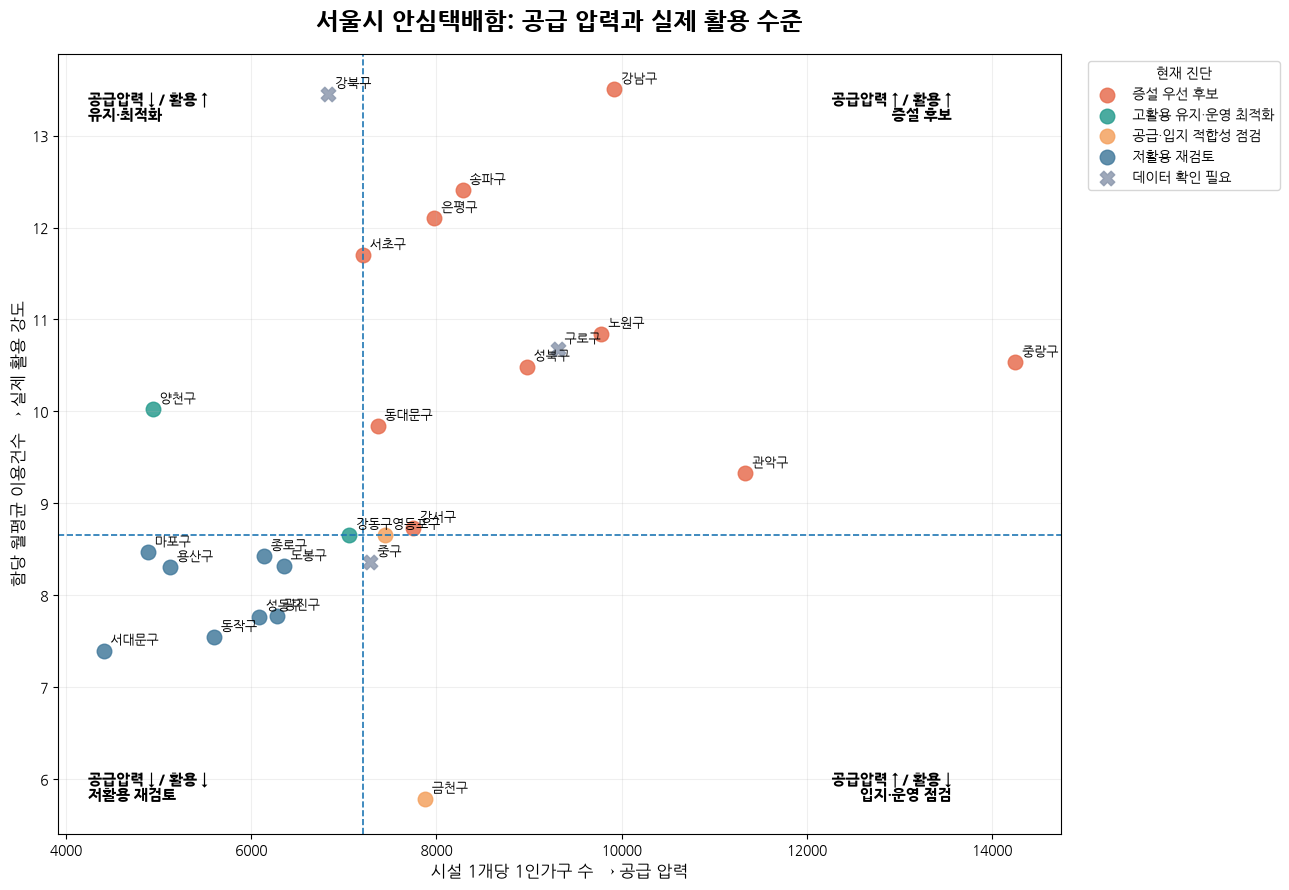

저장 완료: outputs\figures\district_supply_pressure_vs_utilization.png


In [17]:
pressure_cut = float(
    df_final["pressure_median"]
    .dropna()
    .iloc[0]
)

utilization_cut = float(
    df_final["utilization_median"]
    .dropna()
    .iloc[0]
)

print(f"공급압력 기준선: {pressure_cut:,.0f} 가구/시설")
print(f"활용도 기준선: {utilization_cut:.2f} 건/함·월")

plot_df = df_analysis.copy()

group_styles = {
    "증설 우선 후보": {
        "color": "#E76F51",
        "marker": "o"
    },
    "고활용 유지·운영 최적화": {
        "color": "#2A9D8F",
        "marker": "o"
    },
    "공급·입지 적합성 점검": {
        "color": "#F4A261",
        "marker": "o"
    },
    "저활용 재검토": {
        "color": "#457B9D",
        "marker": "o"
    },
    "데이터 확인 필요": {
        "color": "#8D99AE",
        "marker": "X"
    }
}

fig, ax = plt.subplots(figsize=(13, 9))

for group, style in group_styles.items():

    temp = plot_df[
        plot_df["diagnostic_group_label"] == group
    ]

    ax.scatter(
        temp["one_person_households_per_facility"],
        temp["weighted_monthly_usage_per_locker"],
        s=110,
        alpha=0.85,
        label=group,
        color=style["color"],
        marker=style["marker"]
    )

for _, row in plot_df.iterrows():

    ax.annotate(
        row["district"],
        (
            row["one_person_households_per_facility"],
            row["weighted_monthly_usage_per_locker"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.axvline(
    pressure_cut,
    linestyle="--",
    linewidth=1.2
)

ax.axhline(
    utilization_cut,
    linestyle="--",
    linewidth=1.2
)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.text(
    x_max * 0.92,
    y_max * 0.97,
    "공급압력 ↑ / 활용 ↑\n증설 후보",
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    x_min + (x_max - x_min) * 0.03,
    y_max * 0.97,
    "공급압력 ↓ / 활용 ↑\n유지·최적화",
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    x_max * 0.92,
    y_min + (y_max - y_min) * 0.04,
    "공급압력 ↑ / 활용 ↓\n입지·운영 점검",
    ha="right",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    x_min + (x_max - x_min) * 0.03,
    y_min + (y_max - y_min) * 0.04,
    "공급압력 ↓ / 활용 ↓\n저활용 재검토",
    ha="left",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "서울시 안심택배함: 공급 압력과 실제 활용 수준",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "시설 1개당 1인가구 수 → 공급 압력",
    fontsize=12
)

ax.set_ylabel(
    "함당 월평균 이용건수 → 실제 활용 강도",
    fontsize=12
)

ax.legend(
    title="현재 진단",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

figure_dir = Path("outputs") / "figures"
figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

save_path = (
    figure_dir
    / "district_supply_pressure_vs_utilization.png"
)

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장 완료:", save_path)


📍 중앙값 기준은 시설 1개당 1인가구 7,205가구, 함당 월평균 8.66건이다. 강남구는 공급 압력과 활용도가 모두 높은 위치가 뚜렷해 증설 우선 검토로 분류되었다. 반면 공급압력이 높더라도 활용이 낮은 지역은 바로 증설하지 않고 입지·운영 조건을 먼저 확인하도록 구분했다.


# 9. 핵심 분석 2 - 동일 시설 기준 장기 이용 변화

📍 시설 구성이 바뀌면 연도별 총이용 비교가 왜곡될 수 있으므로, 2021~2025년 동안 계속 관측된 동일 시설만 남긴 Balanced Panel 기준 변화율을 사용한다. ±5% 이내는 큰 방향 변화가 없는 대체로 유지 구간으로 해석한다.

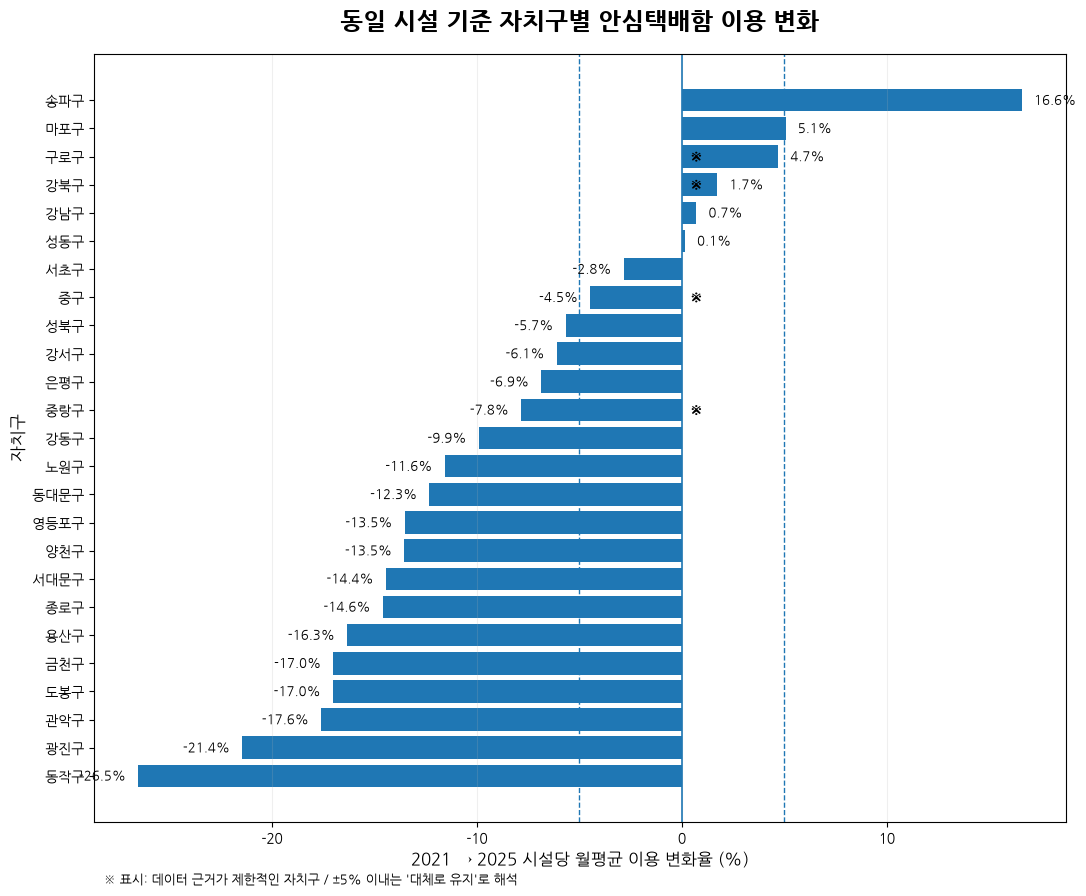

저장 완료: outputs\figures\district_balanced_panel_long_term_change.png


In [18]:
trend_plot = (
    df_analysis[
        [
            "district",
            "usage_change_2021_2025_pct",
            "long_term_trend",
            "final_evidence_strength"
        ]
    ]
    .copy()
    .sort_values(
        "usage_change_2021_2025_pct",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    trend_plot["district"],
    trend_plot["usage_change_2021_2025_pct"]
)

ax.axvline(
    0,
    linewidth=1.2
)

ax.axvline(
    5,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    -5,
    linestyle="--",
    linewidth=1
)

for bar, value in zip(
    bars,
    trend_plot["usage_change_2021_2025_pct"]
):

    if value >= 0:
        x_position = value + 0.6
        ha = "left"

    else:
        x_position = value - 0.6
        ha = "right"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha=ha,
        fontsize=9
    )

for i, row in trend_plot.reset_index(drop=True).iterrows():

    if row["final_evidence_strength"] == "limited":

        ax.text(
            0,
            i,
            "  ※",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

ax.set_title(
    "동일 시설 기준 자치구별 안심택배함 이용 변화",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "2021 → 2025 시설당 월평균 이용 변화율 (%)",
    fontsize=12
)

ax.set_ylabel(
    "자치구",
    fontsize=12
)

ax.grid(
    axis="x",
    alpha=0.2
)

ax.text(
    0.01,
    -0.08,
    "※ 표시: 데이터 근거가 제한적인 자치구 / ±5% 이내는 '대체로 유지'로 해석",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()

figure_dir = Path("outputs") / "figures"

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

save_path = (
    figure_dir
    / "district_balanced_panel_long_term_change.png"
)

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장 완료:", save_path)


📍 송파구는 2021→2025 동일시설 월평균 이용이 +16.6%로 가장 크게 증가했다. 반면 동작구 -26.5%, 광진구 -21.4%, 관악구 -17.6% 등은 장기 감소 폭이 컸다. 현재 공급 압력만 보고 증설을 결정하면 이런 감소 신호를 놓칠 수 있다.


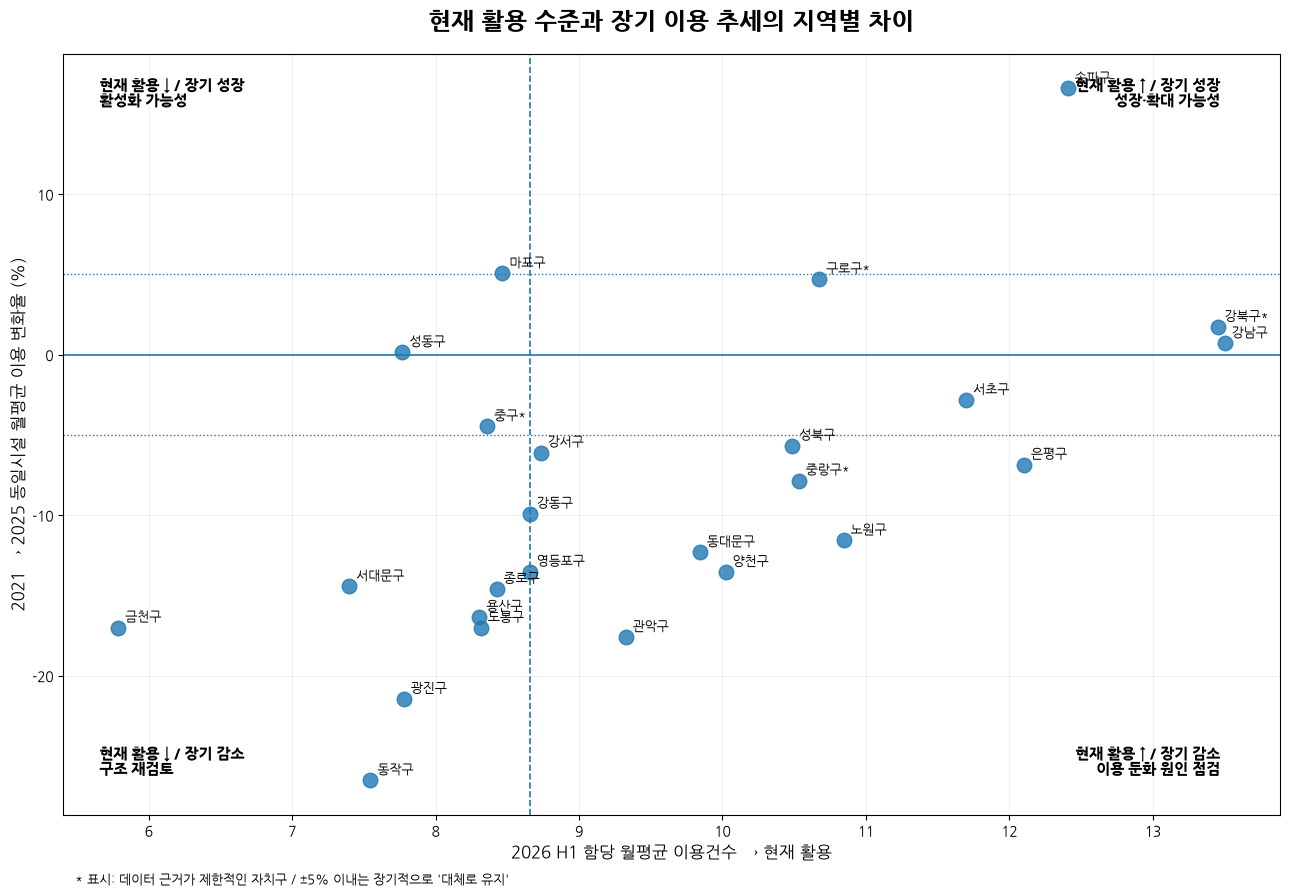

저장 완료: outputs\figures\district_current_utilization_vs_long_term_change.png


In [19]:
plot_df = df_analysis.copy()

utilization_cut = float(
    df_final["utilization_median"]
    .dropna()
    .iloc[0]
)

fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(
    plot_df["weighted_monthly_usage_per_locker"],
    plot_df["usage_change_2021_2025_pct"],
    s=110,
    alpha=0.8
)

for _, row in plot_df.iterrows():

    label = row["district"]

    if row["final_evidence_strength"] == "limited":
        label += "*"

    ax.annotate(
        label,
        (
            row["weighted_monthly_usage_per_locker"],
            row["usage_change_2021_2025_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.axvline(
    utilization_cut,
    linestyle="--",
    linewidth=1.2
)

ax.axhline(
    0,
    linewidth=1.2
)

ax.axhline(
    5,
    linestyle=":",
    linewidth=1
)

ax.axhline(
    -5,
    linestyle=":",
    linewidth=1
)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.text(
    x_max * 0.97,
    y_max * 0.92,
    "현재 활용 ↑ / 장기 성장\n성장·확대 가능성",
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    x_min + (x_max - x_min) * 0.03,
    y_max * 0.92,
    "현재 활용 ↓ / 장기 성장\n활성화 가능성",
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    x_max * 0.97,
    y_min + (y_max - y_min) * 0.05,
    "현재 활용 ↑ / 장기 감소\n이용 둔화 원인 점검",
    ha="right",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    x_min + (x_max - x_min) * 0.03,
    y_min + (y_max - y_min) * 0.05,
    "현재 활용 ↓ / 장기 감소\n구조 재검토",
    ha="left",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "현재 활용 수준과 장기 이용 추세의 지역별 차이",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "2026 H1 함당 월평균 이용건수 → 현재 활용",
    fontsize=12
)

ax.set_ylabel(
    "2021 → 2025 동일시설 월평균 이용 변화율 (%)",
    fontsize=12
)

ax.grid(
    alpha=0.2
)

ax.text(
    0.01,
    -0.09,
    "* 표시: 데이터 근거가 제한적인 자치구 / ±5% 이내는 장기적으로 '대체로 유지'",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()

figure_dir = Path("outputs") / "figures"
figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

save_path = (
    figure_dir
    / "district_current_utilization_vs_long_term_change.png"
)

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장 완료:", save_path)


📍 현재 활용과 장기 추세를 함께 보면 지역의 상황이 더 구체적으로 갈린다. 예를 들어 강남구는 높은 현재 활용과 장기 유지가 함께 나타나는 반면, 관악구는 공급 압력이 높은 편이지만 장기 이용이 크게 감소해 증설 전 이용감소 원인 점검이 더 적절하다.


# 10. 수요 특성과 실제 활용의 관계

📍 자치구 25개를 대상으로 Spearman 순위상관을 확인한다. 표본이 25개 자치구뿐이므로 인과관계가 아니라 탐색적 관계로 해석한다.

In [22]:
variables = {
    "1인가구 수": "one_person_total",
    "20~39세 1인가구 수": "one_person_age_20_39",
    "20~39세 비중": "age_20_39_share_pct",
    "시설당 1인가구 수": "one_person_households_per_facility",
    "1만 가구당 시설 수": "facilities_per_10k_one_person_households",
    "함당 월평균 이용": "weighted_monthly_usage_per_locker",
    "1만 가구당 월이용": "monthly_usage_per_10k_one_person_households",
    "장기 이용 변화율": "usage_change_2021_2025_pct"
}

target = "weighted_monthly_usage_per_locker"

results = []

for label, column in variables.items():

    if column == target:
        continue

    rho, p_value = spearmanr(
        df_analysis[column],
        df_analysis[target],
        nan_policy="omit"
    )

    results.append({
        "변수": label,
        "Spearman_rho": rho,
        "p_value": p_value
    })

corr_result = pd.DataFrame(results)

corr_result["절대상관"] = (
    corr_result["Spearman_rho"]
    .abs()
)

corr_result = (
    corr_result
    .sort_values(
        "절대상관",
        ascending=False
    )
    .drop(columns="절대상관")
    .reset_index(drop=True)
)

corr_result["Spearman_rho"] = (
    corr_result["Spearman_rho"]
    .round(3)
)

corr_result["p_value"] = (
    corr_result["p_value"]
    .round(4)
)

corr_result


,변수,Spearman_rho,p_value
0,장기 이용 변화율,0.615,0.0011
1,시설당 1인가구 수,0.596,0.0017
2,1만 가구당 시설 수,-0.596,0.0017
3,20~39세 비중,-0.522,0.0074
4,1인가구 수,0.264,0.2025
5,1만 가구당 월이용,0.254,0.2208
6,20~39세 1인가구 수,0.002,0.9942


📍 현재 함당 이용과 가장 강하게 함께 움직인 변수는 장기 이용 변화율(ρ=0.615, p=0.0011)과 시설당 1인가구 수(ρ=0.596, p=0.0017)였다. 반면 전체 1인가구 수 자체는 유의한 관계가 확인되지 않았다. 즉 수요 인구가 많다는 사실만보다 현재 공급 대비 수요 압력과 실제 이용 흐름을 함께 보는 것이 더 중요했다.
20~39세 비중은 음의 상관(ρ=-0.522)을 보였지만, 자치구 단위의 탐색적 결과이므로 청년 비중이 이용을 낮춘다고 인과적으로 해석하지 않았다.


In [23]:
df_reliable = df_analysis[
    df_analysis["usage_coverage_pct"] >= 80
].copy()

print("전체 자치구 수:", len(df_analysis))
print("커버리지 80% 이상:", len(df_reliable))

check_variables = {
    "1인가구 수": "one_person_total",
    "20~39세 1인가구 수": "one_person_age_20_39",
    "20~39세 비중": "age_20_39_share_pct",
    "시설당 1인가구 수": "one_person_households_per_facility",
    "장기 이용 변화율": "usage_change_2021_2025_pct"
}

target = "weighted_monthly_usage_per_locker"

results = []

for label, column in check_variables.items():

    rho_all, p_all = spearmanr(
        df_analysis[column],
        df_analysis[target],
        nan_policy="omit"
    )

    rho_reliable, p_reliable = spearmanr(
        df_reliable[column],
        df_reliable[target],
        nan_policy="omit"
    )

    results.append({
        "변수": label,
        "전체_rho": rho_all,
        "전체_p": p_all,
        "커버리지80_rho": rho_reliable,
        "커버리지80_p": p_reliable,
        "rho차이": rho_reliable - rho_all
    })

robust_corr = pd.DataFrame(results)

for col in [
    "전체_rho",
    "전체_p",
    "커버리지80_rho",
    "커버리지80_p",
    "rho차이"
]:
    robust_corr[col] = robust_corr[col].round(3)

robust_corr


전체 자치구 수: 25
커버리지 80% 이상: 22


,변수,전체_rho,전체_p,커버리지80_rho,커버리지80_p,rho차이
0,1인가구 수,0.264,0.203,0.313,0.156,0.050
1,20~39세 1인가구 수,0.002,0.994,0.029,0.899,0.027
2,20~39세 비중,-0.522,0.007,-0.511,0.015,0.011
3,시설당 1인가구 수,0.596,0.002,0.645,0.001,0.049
4,장기 이용 변화율,0.615,0.001,0.613,0.002,-0.003


📍 커버리지 80% 이상인 22개 자치구만 남겨도 시설당 1인가구 수(ρ=0.645), 장기 이용 변화율(ρ=0.613), 20~39세 비중(ρ=-0.511)의 방향과 크기가 크게 달라지지 않았다. 핵심 관계가 일부 저커버리지 지역에만 의해 만들어진 결과는 아닌 것으로 판단했다.


# 11. 시설 단위 심화 분석

📍 자치구 평균만으로 정책을 결정하면 같은 구 안의 고활용·저활용 시설 차이가 가려질 수 있다. 2026년 상반기 현재 시설 중 이용건수가 관측된 시설을 BigQuery에서 다시 불러와 시설 수준으로 내려간다.

In [24]:
facility_query = """
SELECT
    locker_stat_id,
    facility_entity_id,
    district,
    facility_name,
    address,

    latitude,
    longitude,

    locker_count,

    usage_count,
    calculated_monthly_avg_usage,
    monthly_usage_per_locker,

    facility_analysis_status,
    current_vs_metrics_status_conflict,

    data_quality_status

FROM
    `mission17-locker-jh-2608.analytics_seoul_locker.int_locker_period_metrics`

WHERE
    period = '2026_h1'

    AND is_in_current_location_source = TRUE

    AND has_usage_observation = TRUE
"""

df_facility = client.query(
    facility_query
).to_dataframe()

print("시설 데이터 크기:", df_facility.shape)

print(
    "고유 시설 수:",
    df_facility["locker_stat_id"].nunique()
)

print(
    "자치구 수:",
    df_facility["district"].nunique()
)

print(
    "시설 ID 중복:",
    df_facility["locker_stat_id"]
    .duplicated()
    .sum()
)

print("\n결측치:")
print(
    df_facility.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

df_facility.head()


시설 데이터 크기: (215, 14)
고유 시설 수: 215
자치구 수: 25
시설 ID 중복: 0

결측치:
locker_count                1
monthly_usage_per_locker    1
dtype: int64


,locker_stat_id,facility_entity_id,district,facility_name,address,latitude,longitude,locker_count,usage_count,calculated_monthly_avg_usage,monthly_usage_per_locker,facility_analysis_status,current_vs_metrics_status_conflict,data_quality_status
0,STAT_594cee10f6bf,STAT_594cee10f6bf,동작구,kb국민은행 동작구청지점,장승배기로 161,37.512528,126.939942,47,926.0,154.333333,3.283688,current_matched_operating,False,ok
1,STAT_fdc8088d2280,STAT_fdc8088d2280,송파구,가락2동치안센터,오금로46길 55,37.493222,127.132364,12,646.0,107.666667,8.972222,current_matched_operating,False,ok
2,STAT_5c873e7265ba,STAT_5c873e7265ba,강서구,가로공원공영주차장1번출구,가로공원로 189,37.537235,126.837039,19,789.0,131.500000,6.921053,current_matched_operating,False,ok
3,STAT_12ddd3aab93b,STAT_12ddd3aab93b,용산구,갈월종합사회복지관,두텁바위로 25,37.545774,126.974824,26,1676.0,279.333333,10.743590,current_matched_operating,False,ok
4,STAT_93f602e43c1c,STAT_93f602e43c1c,은평구,갈현1동 주민센터,갈현로 301,37.623688,126.916689,26,1188.0,198.000000,7.615385,current_matched_operating,False,ok


📍 2026년 상반기 이용실적이 있는 현재 시설은 215개이며 자치구 25개가 모두 포함된다. locker_count와 함당 이용효율이 비어 있는 시설은 1개뿐이었다.


In [25]:
missing_locker = df_facility[
    df_facility["locker_count"].isna()
].copy()

print("=== locker_count 결측 시설 ===")
display(
    missing_locker[
        [
            "locker_stat_id",
            "district",
            "facility_name",
            "address",
            "usage_count",
            "calculated_monthly_avg_usage",
            "locker_count",
            "monthly_usage_per_locker",
            "facility_analysis_status",
            "data_quality_status"
        ]
    ]
)

df_facility_eff = df_facility[
    df_facility["locker_count"].notna()
    & df_facility["monthly_usage_per_locker"].notna()
].copy()

print("\n전체 현재 이용관측 시설:", len(df_facility))
print("함당 이용효율 분석 가능 시설:", len(df_facility_eff))
print("효율 분석 제외 시설:", len(df_facility) - len(df_facility_eff))

district_dispersion = (
    df_facility_eff
    .groupby("district")
    .agg(
        facility_count=("locker_stat_id", "nunique"),

        mean_usage_per_locker=(
            "monthly_usage_per_locker",
            "mean"
        ),

        median_usage_per_locker=(
            "monthly_usage_per_locker",
            "median"
        ),

        std_usage_per_locker=(
            "monthly_usage_per_locker",
            "std"
        ),

        min_usage_per_locker=(
            "monthly_usage_per_locker",
            "min"
        ),

        max_usage_per_locker=(
            "monthly_usage_per_locker",
            "max"
        )
    )
    .reset_index()
)

# CV는 자치구 내부 시설 이용편차를 비교하기 위한 탐색 지표
district_dispersion["cv_usage_per_locker"] = (
    district_dispersion["std_usage_per_locker"]
    / district_dispersion["mean_usage_per_locker"]
)

district_dispersion["max_min_gap"] = (
    district_dispersion["max_usage_per_locker"]
    - district_dispersion["min_usage_per_locker"]
)

round_columns = [
    "mean_usage_per_locker",
    "median_usage_per_locker",
    "std_usage_per_locker",
    "min_usage_per_locker",
    "max_usage_per_locker",
    "cv_usage_per_locker",
    "max_min_gap"
]

district_dispersion[round_columns] = (
    district_dispersion[round_columns]
    .round(2)
)

district_dispersion = (
    district_dispersion
    .sort_values(
        "cv_usage_per_locker",
        ascending=False
    )
    .reset_index(drop=True)
)

district_dispersion


=== locker_count 결측 시설 ===


,locker_stat_id,district,facility_name,address,usage_count,calculated_monthly_avg_usage,locker_count,monthly_usage_per_locker,facility_analysis_status,data_quality_status
151,STAT_c30d9a40d4f3,서초구,양재공영주차장,양재천로 125-10,295.0,49.166667,<NA>,NaN,current_matched_operating,ok



전체 현재 이용관측 시설: 215
함당 이용효율 분석 가능 시설: 214
효율 분석 제외 시설: 1


,district,facility_count,mean_usage_per_locker,median_usage_per_locker,std_usage_per_locker,min_usage_per_locker,max_usage_per_locker,cv_usage_per_locker,max_min_gap
0,도봉구,7,8.74,6.17,6.96,0.18,20.06,0.80,19.89
1,강동구,10,8.51,8.87,6.13,0.85,15.97,0.72,15.13
2,성동구,8,6.72,6.34,4.35,0.18,15.21,0.65,15.03
3,동작구,12,7.59,7.61,4.29,2.06,14.14,0.56,12.08
4,관악구,13,9.13,8.87,4.98,3.21,20.32,0.55,17.12
5,마포구,15,7.74,7.50,4.19,1.24,17.27,0.54,16.03
6,노원구,7,9.88,9.61,5.19,3.16,17.73,0.53,14.57
7,양천구,10,9.93,9.17,5.15,4.13,22.48,0.52,18.35
8,영등포구,11,8.81,10.05,4.47,2.40,16.02,0.51,13.61
9,동대문구,9,10.10,9.72,5.03,4.43,16.53,0.50,12.10


📍 함당 이용효율 분석에는 214개 시설을 사용했다. 자치구 내부 CV가 큰 지역으로 도봉구(0.80), 강동구(0.72), 성동구(0.65), 동작구(0.56), 관악구(0.55) 등이 확인됐다. 이는 같은 자치구라도 시설별 활용 수준이 상당히 다를 수 있음을 보여준다.


In [26]:
district_reference = (
    df_facility_eff
    .groupby("district")
    .agg(
        district_facility_count=(
            "locker_stat_id",
            "nunique"
        ),

        district_mean_usage_per_locker=(
            "monthly_usage_per_locker",
            "mean"
        ),

        district_median_usage_per_locker=(
            "monthly_usage_per_locker",
            "median"
        )
    )
    .reset_index()
)

facility_detail = (
    df_facility_eff
    .merge(
        district_reference,
        on="district",
        how="left"
    )
)

facility_detail["usage_rank_in_district"] = (
    facility_detail
    .groupby("district")["monthly_usage_per_locker"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

facility_detail["usage_percentile_in_district"] = (
    facility_detail
    .groupby("district")["monthly_usage_per_locker"]
    .rank(
        pct=True
    )
)

facility_detail["vs_district_median_pct"] = (
    (
        facility_detail["monthly_usage_per_locker"]
        / facility_detail["district_median_usage_per_locker"]
        - 1
    )
    * 100
)

district_strategy = (
    df_analysis[
        [
            "district",
            "final_action_label",
            "action_tier",
            "final_evidence_strength",
            "long_term_trend",
            "recent_trend"
        ]
    ]
    .drop_duplicates("district")
)

facility_detail = facility_detail.merge(
    district_strategy,
    on="district",
    how="left"
)

# 자치구 내부 상대 위치이며 정책적 절대 기준은 아님
facility_detail["facility_relative_status"] = pd.cut(
    facility_detail["usage_percentile_in_district"],
    bins=[0, 0.25, 0.75, 1.0],
    labels=[
        "자치구 내 저활용",
        "자치구 내 중간",
        "자치구 내 고활용"
    ],
    include_lowest=True
)

facility_result = facility_detail[
    [
        "district",
        "facility_name",
        "address",

        "locker_count",
        "calculated_monthly_avg_usage",
        "monthly_usage_per_locker",

        "district_facility_count",
        "district_median_usage_per_locker",

        "usage_rank_in_district",
        "usage_percentile_in_district",
        "vs_district_median_pct",
        "facility_relative_status",

        "final_action_label",
        "action_tier",
        "final_evidence_strength"
    ]
].copy()

round_cols = [
    "calculated_monthly_avg_usage",
    "monthly_usage_per_locker",
    "district_median_usage_per_locker",
    "usage_percentile_in_district",
    "vs_district_median_pct"
]

facility_result[round_cols] = (
    facility_result[round_cols]
    .round(2)
)

print("시설 결과 크기:", facility_result.shape)

facility_result.head()


시설 결과 크기: (214, 15)


,district,facility_name,address,locker_count,calculated_monthly_avg_usage,monthly_usage_per_locker,district_facility_count,district_median_usage_per_locker,usage_rank_in_district,usage_percentile_in_district,vs_district_median_pct,facility_relative_status,final_action_label,action_tier,final_evidence_strength
0,동작구,kb국민은행 동작구청지점,장승배기로 161,47,154.33,3.28,12,7.61,9,0.33,-56.82,자치구 내 중간,저활용 구조 재검토 우선,3,medium
1,송파구,가락2동치안센터,오금로46길 55,12,107.67,8.97,10,11.28,8,0.30,-20.46,자치구 내 중간,증설 조건부 검토,2,medium
2,강서구,가로공원공영주차장1번출구,가로공원로 189,19,131.50,6.92,13,7.66,8,0.46,-9.62,자치구 내 중간,증설 조건부 검토,2,high
3,용산구,갈월종합사회복지관,두텁바위로 25,26,279.33,10.74,8,7.61,3,0.75,41.18,자치구 내 중간,최근 반등 가능성 점검,3,high
4,은평구,갈현1동 주민센터,갈현로 301,26,198.00,7.62,8,11.75,7,0.25,-35.21,자치구 내 저활용,증설 조건부 검토,2,medium


📍 자치구 전략이 같더라도 개별 시설의 상대 성과는 다르다. 따라서 증설 후보 지역에서도 모든 시설을 동일하게 확대하기보다, 고활용 시설의 위치·운영 특성을 먼저 확인하고 저활용 시설과 구분해 대응하는 것이 적절하다.


In [27]:
focus_districts = [
    "관악구",
    "강남구",
    "송파구",
    "금천구",
    "광진구",
    "동작구"
]

focus_facilities = (
    facility_result[
        facility_result["district"].isin(focus_districts)
    ]
    .sort_values(
        [
            "district",
            "monthly_usage_per_locker"
        ],
        ascending=[
            True,
            False
        ]
    )
)

focus_facilities


,district,facility_name,address,locker_count,calculated_monthly_avg_usage,monthly_usage_per_locker,district_facility_count,district_median_usage_per_locker,usage_rank_in_district,usage_percentile_in_district,vs_district_median_pct,facility_relative_status,final_action_label,action_tier,final_evidence_strength
41,강남구,대치4동 주민센터,도곡로77길 23,47,913.50,19.44,7,12.39,1,1.00,56.92,자치구 내 고활용,증설 우선 검토,1,medium
40,강남구,대치2동 주민센터,영동대로65길 24,19,289.33,15.23,7,12.39,2,0.86,22.95,자치구 내 고활용,증설 우선 검토,1,medium
154,강남구,역삼1동 주민센터,역삼로7길 16,19,272.17,14.32,7,12.39,3,0.71,15.65,자치구 내 중간,증설 우선 검토,1,medium
35,강남구,논현1동주민센터,학동로20길 25,19,235.33,12.39,7,12.39,4,0.57,0.00,자치구 내 중간,증설 우선 검토,1,medium
44,강남구,도곡2동주민센터,남부순환로378길 34-9,26,312.33,12.01,7,12.39,5,0.43,-3.01,자치구 내 중간,증설 우선 검토,1,medium
155,강남구,역삼청소년수련관,논현로64길 7,12,76.33,6.36,7,12.39,6,0.29,-48.64,자치구 내 중간,증설 우선 검토,1,medium
43,강남구,도곡1동 주민센터,도곡로18길 57,19,74.67,3.93,7,12.39,7,0.14,-68.27,자치구 내 저활용,증설 우선 검토,1,medium
173,관악구,인헌동주민센터,남부순환로246가길 20,19,386.17,20.32,13,8.87,1,1.00,129.18,자치구 내 고활용,증설 전 이용감소 원인 점검,2,high
18,관악구,관악구청,관악로 145,19,318.83,16.78,13,8.87,2,0.92,89.22,자치구 내 고활용,증설 전 이용감소 원인 점검,2,high
200,관악구,행운동주민센터,행운1길 43,26,330.83,12.72,13,8.87,3,0.85,43.48,자치구 내 고활용,증설 전 이용감소 원인 점검,2,high


In [28]:
status_counts = (
    facility_result
    .groupby(
        [
            "district",
            "facility_relative_status"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

for col in [
    "자치구 내 고활용",
    "자치구 내 중간",
    "자치구 내 저활용"
]:
    if col not in status_counts.columns:
        status_counts[col] = 0

status_counts = status_counts.rename(
    columns={
        "자치구 내 고활용": "high_utilization_facilities",
        "자치구 내 중간": "middle_utilization_facilities",
        "자치구 내 저활용": "low_utilization_facilities"
    }
)

top_facility = (
    facility_result
    .sort_values(
        "monthly_usage_per_locker",
        ascending=False
    )
    .groupby(
        "district",
        as_index=False
    )
    .first()
    [
        [
            "district",
            "facility_name",
            "monthly_usage_per_locker"
        ]
    ]
    .rename(
        columns={
            "facility_name": "top_facility_name",
            "monthly_usage_per_locker": "top_facility_usage_per_locker"
        }
    )
)

bottom_facility = (
    facility_result
    .sort_values(
        "monthly_usage_per_locker",
        ascending=True
    )
    .groupby(
        "district",
        as_index=False
    )
    .first()
    [
        [
            "district",
            "facility_name",
            "monthly_usage_per_locker"
        ]
    ]
    .rename(
        columns={
            "facility_name": "bottom_facility_name",
            "monthly_usage_per_locker": "bottom_facility_usage_per_locker"
        }
    )
)

dispersion_summary = district_dispersion[
    [
        "district",
        "facility_count",
        "mean_usage_per_locker",
        "median_usage_per_locker",
        "cv_usage_per_locker",
        "max_min_gap"
    ]
].copy()

strategy_summary = (
    df_analysis[
        [
            "district",
            "final_action_label",
            "action_tier",
            "final_evidence_strength",
            "long_term_trend",
            "recent_trend"
        ]
    ]
    .drop_duplicates(
        "district"
    )
)

district_facility_summary = (
    dispersion_summary
    .merge(
        status_counts,
        on="district",
        how="left"
    )
    .merge(
        top_facility,
        on="district",
        how="left"
    )
    .merge(
        bottom_facility,
        on="district",
        how="left"
    )
    .merge(
        strategy_summary,
        on="district",
        how="left"
    )
)

district_facility_summary["high_utilization_share_pct"] = (
    district_facility_summary["high_utilization_facilities"]
    / district_facility_summary["facility_count"]
    * 100
)

district_facility_summary["low_utilization_share_pct"] = (
    district_facility_summary["low_utilization_facilities"]
    / district_facility_summary["facility_count"]
    * 100
)

# CV 구간은 시설 내부 편차를 설명하기 위한 탐색적 기준
def classify_dispersion(row):

    if row["facility_count"] < 5:
        return "시설 수 적어 해석 주의"

    elif row["cv_usage_per_locker"] >= 0.50:
        return "시설 간 편차 큼"

    elif row["cv_usage_per_locker"] >= 0.30:
        return "시설 간 편차 중간"

    else:
        return "시설 간 편차 낮음"

district_facility_summary["facility_dispersion_type"] = (
    district_facility_summary.apply(
        classify_dispersion,
        axis=1
    )
)

def make_facility_implication(row):

    if row["facility_count"] < 5:
        return "시설 수가 적어 개별 시설 중심 추가 확인"

    elif row["cv_usage_per_locker"] >= 0.50:
        return "자치구 일괄 대응보다 고활용 거점 보강과 저활용 시설 점검 병행"

    elif (
        row["cv_usage_per_locker"] < 0.30
        and row["mean_usage_per_locker"] < 9
    ):
        return "시설 전반의 저활용 가능성 검토"

    else:
        return "자치구 전략 유지하되 시설별 성과 차이 함께 모니터링"

district_facility_summary["facility_level_implication"] = (
    district_facility_summary.apply(
        make_facility_implication,
        axis=1
    )
)

round_cols = [
    "mean_usage_per_locker",
    "median_usage_per_locker",
    "cv_usage_per_locker",
    "max_min_gap",
    "top_facility_usage_per_locker",
    "bottom_facility_usage_per_locker",
    "high_utilization_share_pct",
    "low_utilization_share_pct"
]

district_facility_summary[round_cols] = (
    district_facility_summary[round_cols]
    .round(2)
)

district_facility_summary = (
    district_facility_summary
    .sort_values(
        [
            "action_tier",
            "cv_usage_per_locker"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

table_dir = Path("outputs") / "tables"

table_dir.mkdir(
    parents=True,
    exist_ok=True
)

save_path = (
    table_dir
    / "district_facility_performance_summary.csv"
)

district_facility_summary.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "요약 테이블 크기:",
    district_facility_summary.shape
)

print(
    "저장 완료:",
    save_path
)

district_facility_summary


요약 테이블 크기: (25, 22)
저장 완료: outputs\tables\district_facility_performance_summary.csv


,district,facility_count,mean_usage_per_locker,median_usage_per_locker,cv_usage_per_locker,max_min_gap,low_utilization_facilities,middle_utilization_facilities,high_utilization_facilities,top_facility_name,...,bottom_facility_usage_per_locker,final_action_label,action_tier,final_evidence_strength,long_term_trend,recent_trend,high_utilization_share_pct,low_utilization_share_pct,facility_dispersion_type,facility_level_implication
0,강남구,7,11.95,12.39,0.44,15.51,1,4,2,대치4동 주민센터,...,3.93,증설 우선 검토,1,medium,대체로 유지,최근 증가,28.57,14.29,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링
1,관악구,13,9.13,8.87,0.55,17.12,3,6,4,인헌동주민센터,...,3.21,증설 전 이용감소 원인 점검,2,high,장기 감소,최근 감소,30.77,23.08,시설 간 편차 큼,자치구 일괄 대응보다 고활용 거점 보강과 저활용 시설 점검 병행
2,노원구,7,9.88,9.61,0.53,14.57,1,4,2,상계역 자전거대여소,...,3.16,증설 전 이용감소 원인 점검,2,medium,장기 감소,최근 감소,28.57,14.29,시설 간 편차 큼,자치구 일괄 대응보다 고활용 거점 보강과 저활용 시설 점검 병행
3,동대문구,9,10.10,9.72,0.50,12.10,2,4,3,답십리도서관,...,4.43,증설 전 이용감소 원인 점검,2,medium,장기 감소,최근 감소,33.33,22.22,시설 간 편차 큼,자치구 일괄 대응보다 고활용 거점 보강과 저활용 시설 점검 병행
4,송파구,10,11.64,11.28,0.46,18.22,2,5,3,석촌동주민센터,...,1.81,증설 조건부 검토,2,medium,장기 증가,최근 감소,30.00,20.00,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링
5,서초구,6,10.86,10.10,0.45,13.58,1,3,2,방배열린문화센터,...,5.75,증설 조건부 검토,2,medium,대체로 유지,최근 유지,33.33,16.67,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링
6,강서구,13,8.58,7.66,0.44,14.22,3,6,4,볏골공원공영주차장,...,4.62,증설 조건부 검토,2,high,장기 감소,최근 유지,30.77,23.08,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링
7,은평구,8,11.85,11.75,0.43,14.67,2,4,2,역촌동 주민센터,...,4.00,증설 조건부 검토,2,medium,장기 감소,최근 유지,25.00,25.00,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링
8,성북구,7,10.39,10.62,0.41,12.20,1,4,2,장위1동 주민센터,...,3.66,증설 조건부 검토,2,medium,장기 감소,최근 유지,28.57,14.29,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링
9,중랑구,5,10.02,8.39,0.39,7.90,1,2,2,상봉1동주민센터,...,6.48,증설 판단 전 데이터 보강,2,limited,장기 감소,최근 감소,40.00,20.00,시설 간 편차 중간,자치구 전략 유지하되 시설별 성과 차이 함께 모니터링


📍 자치구 25개에 대해 시설 수, 평균·중앙 이용효율, CV, 고·저활용 시설 수와 비중, 최고·최저 시설, 최종 액션을 22개 컬럼으로 정리했다. 이 테이블이 이후 Looker Studio의 시설 수준 진단 근거로 사용된다.


# 12. Python 분석 결과 BigQuery 재적재

📍 Python에서 만든 시설 수준 요약 결과를 BigQuery 분석 데이터셋에 다시 적재한다. 동일 코드를 재실행했을 때 결과 테이블이 최신 분석 결과로 갱신되도록 WRITE_TRUNCATE를 사용한다.

In [29]:
df_upload = district_facility_summary.copy()

string_columns = [
    "district",
    "top_facility_name",
    "bottom_facility_name",
    "final_action_label",
    "final_evidence_strength",
    "long_term_trend",
    "recent_trend",
    "facility_dispersion_type",
    "facility_level_implication"
]

for col in string_columns:
    df_upload[col] = df_upload[col].astype("string")

table_id = (
    "mission17-locker-jh-2608."
    "analytics_seoul_locker."
    "mart_district_facility_summary_python"
)

# 재실행 시 기존 분석 테이블을 최신 결과로 교체
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)

load_job = client.load_table_from_dataframe(
    df_upload,
    table_id,
    job_config=job_config
)

load_job.result()

print("BigQuery 적재 완료 ✅")
print("테이블:", table_id)
print("적재 행 수:", len(df_upload))


BigQuery 적재 완료 ✅
테이블: mission17-locker-jh-2608.analytics_seoul_locker.mart_district_facility_summary_python
적재 행 수: 25


📍 Python에서 생성한 자치구별 시설 성과 요약 25행을 mart_district_facility_summary_python 테이블에 적재했다.


In [30]:
check_query = """
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT district) AS district_count
FROM
    `mission17-locker-jh-2608.analytics_seoul_locker.mart_district_facility_summary_python`
"""

df_check = client.query(check_query).to_dataframe()

df_check


,row_count,district_count
0,25,25


📍 BigQuery에서 다시 조회한 결과 row_count = 25, district_count = 25로 확인되어 자치구별 한 행씩 정상 적재됐다.


# 13. Looker Studio 지도용 자치구 경계 데이터

📍 자치구별 결과를 지도에 표시하기 위해 시군구 경계 SHP를 GeoPandas로 가공한다.

In [32]:
print("현재 작업 폴더:", Path.cwd())


현재 작업 폴더: c:\Users\lucy5\Desktop\mission17-seoul-locker\notebooks


📍 원본 SHP의 좌표계와 컬럼을 확인한다. 원본 좌표계는 EPSG:5186.

In [33]:
shp_path = (
    Path.cwd().parent
    / "data"
    / "boundary"
    / "BND_SIGUNGU_PG.shp"
)

print("SHP 경로:", shp_path)
print("파일 존재:", shp_path.exists())

gdf = gpd.read_file(shp_path)

print("행 수:", len(gdf))
print("좌표계:", gdf.crs)
print("컬럼:", gdf.columns.tolist())

gdf.head()


SHP 경로: c:\Users\lucy5\Desktop\mission17-seoul-locker\data\boundary\BND_SIGUNGU_PG.shp
파일 존재: True
행 수: 252
좌표계: EPSG:5186
컬럼: ['BASE_DATE', 'SIGUNGU_CD', 'SIGUNGU_NM', 'geometry']


,BASE_DATE,SIGUNGU_CD,SIGUNGU_NM,geometry
0,20250630,11010,종로구,"POLYGON ((197800.72 559064.245, 197782.581 558..."
1,20250630,11020,중구,"POLYGON ((202043.919 552491.141, 202063.481 55..."
2,20250630,11030,용산구,"POLYGON ((197275.979 550595.299, 197275.977 55..."
3,20250630,11040,성동구,"POLYGON ((203535.345 552606.268, 203569.567 55..."
4,20250630,11050,광진구,"POLYGON ((208981.056 552544.566, 209031.744 55..."


📍 시군구 코드가 11로 시작하는 서울특별시 자치구만 추출하고 25개가 모두 존재하는지 검증한다.

In [34]:
seoul_gu = gdf[
    gdf["SIGUNGU_CD"].astype(str).str.startswith("11")
].copy()

print("서울 자치구 수:", len(seoul_gu))
print()

print(
    seoul_gu[
        ["SIGUNGU_CD", "SIGUNGU_NM"]
    ]
    .sort_values("SIGUNGU_CD")
    .to_string(index=False)
)


서울 자치구 수: 25

SIGUNGU_CD SIGUNGU_NM
     11010        종로구
     11020         중구
     11030        용산구
     11040        성동구
     11050        광진구
     11060       동대문구
     11070        중랑구
     11080        성북구
     11090        강북구
     11100        도봉구
     11110        노원구
     11120        은평구
     11130       서대문구
     11140        마포구
     11150        양천구
     11160        강서구
     11170        구로구
     11180        금천구
     11190       영등포구
     11200        동작구
     11210        관악구
     11220        서초구
     11230        강남구
     11240        송파구
     11250        강동구


📍 웹 지도에서 사용할 수 있도록 경계를 WGS84(EPSG:4326)로 변환한다. 변환 후 geometry 유효성과 전체 범위를 함께 확인한다.

In [35]:
seoul_gu_4326 = seoul_gu.to_crs(epsg=4326)

print("변환 후 좌표계:", seoul_gu_4326.crs)
print("geometry 타입:", seoul_gu_4326.geometry.geom_type.value_counts())
print("유효하지 않은 geometry:", (~seoul_gu_4326.geometry.is_valid).sum())
print("전체 범위:", seoul_gu_4326.total_bounds)

seoul_gu_4326.head()


변환 후 좌표계: EPSG:4326
geometry 타입: Polygon    25
Name: count, dtype: int64
유효하지 않은 geometry: 0
전체 범위: [126.76448396  37.42829748 127.18379493  37.70145527]


,BASE_DATE,SIGUNGU_CD,SIGUNGU_NM,geometry
0,20250630,11010,종로구,"POLYGON ((126.97508 37.63118, 126.97488 37.630..."
1,20250630,11020,중구,"POLYGON ((127.02314 37.57196, 127.02336 37.571..."
2,20250630,11030,용산구,"POLYGON ((126.96917 37.55488, 126.96917 37.554..."
3,20250630,11040,성동구,"POLYGON ((127.04002 37.57299, 127.04041 37.572..."
4,20250630,11050,광진구,"POLYGON ((127.10166 37.5724, 127.10224 37.5721..."


📍 서울 25개 자치구가 모두 Polygon으로 변환되었고 유효하지 않은 geometry는 0건이었다. WGS84 범위도 서울 지역과 일치했다.


📍 Polygon을 WKT 문자열로 변환하고 자치구 중심점 좌표를 함께 만든다. 중심점은 거리 왜곡을 줄이기 위해 원래 투영좌표계에서 계산한 뒤 WGS84로 변환한다.

In [36]:
# 중심점은 투영좌표계에서 계산한 뒤 WGS84로 변환
centroids_5186 = seoul_gu.geometry.centroid

centroids_4326 = gpd.GeoSeries(
    centroids_5186,
    crs=seoul_gu.crs
).to_crs(epsg=4326)

district_boundary_upload = pd.DataFrame({
    "district_code": seoul_gu_4326["SIGUNGU_CD"].astype(str),
    "district": seoul_gu_4326["SIGUNGU_NM"],
    "geometry_wkt": seoul_gu_4326.geometry.to_wkt(),
    "centroid_latitude": centroids_4326.y,
    "centroid_longitude": centroids_4326.x,
})

print("행 수:", len(district_boundary_upload))
print("자치구 중복:", district_boundary_upload["district"].duplicated().sum())
print("결측치:")
print(district_boundary_upload.isna().sum())

district_boundary_upload.head()


행 수: 25
자치구 중복: 0
결측치:
district_code         0
district              0
geometry_wkt          0
centroid_latitude     0
centroid_longitude    0
dtype: int64


,district_code,district,geometry_wkt,centroid_latitude,centroid_longitude
0,11010,종로구,"POLYGON ((126.975085 37.631183, 126.97488 37.6...",37.594915,126.977325
1,11020,중구,"POLYGON ((127.023137 37.571961, 127.023358 37....",37.560131,126.995915
2,11030,용산구,"POLYGON ((126.969172 37.554878, 126.969172 37....",37.531364,126.979911
3,11040,성동구,"POLYGON ((127.04002 37.572994, 127.040407 37.5...",37.551027,127.041052
4,11050,광진구,"POLYGON ((127.101665 37.572401, 127.102238 37....",37.546717,127.085744


📍 경계 테이블은 자치구 코드·자치구명·WKT geometry·중심점 위도·경도 5개 필드로 구성했으며, 25개 자치구 모두 중복과 결측 없이 준비되었다.

📍 가공한 25개 자치구 경계 데이터를 raw_seoul_locker.district_boundary에 적재한다. Looker Studio의 자치구 지도 시각화에 사용한다.

In [37]:
client = bigquery.Client(
    project="mission17-locker-jh-2608"
)

table_id = (
    "mission17-locker-jh-2608."
    "raw_seoul_locker."
    "district_boundary"
)

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE"
)

job = client.load_table_from_dataframe(
    district_boundary_upload,
    table_id,
    job_config=job_config
)

job.result()

table = client.get_table(table_id)

print("업로드 완료 ✅")
print("테이블:", table_id)
print("행 수:", table.num_rows)
print("컬럼 수:", len(table.schema))


업로드 완료 ✅
테이블: mission17-locker-jh-2608.raw_seoul_locker.district_boundary
행 수: 25
컬럼 수: 5


📍 district_boundary 테이블에 25행, 5개 컬럼이 정상 적재되었다.

# 14. 분석 결론


이번 분석에서는 1인가구가 많은 곳 = 무조건 증설로 판단하지 않고 공급 압력 → 실제 활용 → 장기 추세 → 시설 내부 편차 → 데이터 신뢰도 순서로 증거를 쌓았다.

## 핵심 인사이트

1. 절대적인 1인가구 수보다 공급 대비 수요 압력이 중요했다.
   시설당 1인가구 수는 현재 함당 이용과 유의한 양의 관계를 보였지만, 전체 1인가구 수 자체는 뚜렷한 관계가 확인되지 않았다.

2. 현재 이용이 높아도 장기 감소 지역은 바로 증설하면 안 된다.
   관악구처럼 공급 압력이 높지만 장기 이용이 크게 감소한 지역은 증설보다 이용감소 원인과 기존 시설 입지를 먼저 확인하는 편이 타당하다.

3. 현재 활용과 장기 추세가 함께 좋은 지역은 증설 근거가 상대적으로 강하다.
   강남구는 공급 압력과 현재 활용이 모두 높고 장기 이용도 유지되어 최종적으로 증설 우선 검토로 분류됐다.

4. 자치구 평균만으로는 시설별 차이를 설명하기 어렵다.
   여러 자치구에서 시설별 CV가 높게 나타나, 실제 정책은 자치구 단위 판단 뒤 시설 단위 교차검증이 필요했다.

## 해석 시 주의점

- 2026년 자료는 상반기 6개월만 관측되어 연간 자료와 비교할 때 월평균으로 표준화했다.
- 점유율·이용건수 원본 간 설치연도 충돌 1건은 임의 보정하지 않고 품질 플래그로 남겼다.
- 시설 상대 등급과 CV 구간은 정책적 절대 기준이 아니라 탐색적 운영 진단 기준이다.
- 상관분석은 자치구 25개 단위의 탐색 결과이며 인과관계를 의미하지 않는다.

## 최종 산출물 연결

- **BigQuery:** 자치구 최종 진단 Mart + Python 시설 성과 요약 Mart + 자치구 경계 테이블
- **Looker Studio:** 자치구 필터를 기반으로 공급·이용·진단 결과와 시설별 근거를 확인하는 대시보드
- **GitHub:** BigQuery SQL, dbt 모델/YAML 및 프로젝트 실행 파일